In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
import results_analysis_utils as rutils
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
pd.set_option('display.max_columns', 100)

# EXECUTE COPY TO LOCAL DISK PRIMER!!!!!

%load_ext autoreload
%autoreload 2

# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 100 
plt.rcParams['savefig.dpi'] = 100

# ===================================================================
# 1. DICCIONARIOS DE GROUND TRUTH
# ===================================================================

peix_measures = {
    "lubina0": 31.5, "fish_1": 19.4, "caballa": 28.9, "fish_3": 21.6,
    "llobarro": 33.5, "ochoa_no_cinta": 30.5, "ochoa_cinta": 33.5, 
    "ochoa_petita": 30.5, "llobarro_vermell": 29.1, "error": -100, "None": -100,
    "red":29.1, "black":26.6, "no_mark":32.3
}

reverse_peix_measures = {v: k for k, v in peix_measures.items()}


# Ruta base donde están todas las carpetas de días


# Carpeta SOLO para los resultados globales (se crea si no existe)

global_single_dfs = []
global_multi_dfs = []



single_fish_gt = {
    "2024_11_12": 31.5, "2024_11_28": 28.9, 
    "2025_05_08": 33.5, "2025_08_21": 29.1
    
}



multiple_fish_gt = {
    
    #     "2024_11_28": {
    #     "13-14-43_0": {2: "error", 4: "error", 8: "None", 11: "fish_3", 31: "error", 34: "error", 40: "fish_3", 46: "fish_3", 51: "error", 59: "fish_3", 65: "error", 66: "error"},
        
    #     "13-16-54_0": {4: "fish_3", 9: "fish_3", 15: "fish_3", 39: "fish_3", 40: "fish_3", 48: "fish_3", 74: "caballa"},
        
    #     "13-19-06_0": {13: "fish_3", 18: "fish_3", 34: "error", 53: "error"},
        
    #     "13-21-17_0": {3: "error", 7: "error", 13: "error", 14: "error", 36: "caballa", 
    #                    38: "caballa", 42: "error", 67: "caballa", 71: "error", 73: "fish_3", 75: "error", 79: "error"},
        
    #     "13-23-29_0": {2: "error", 3: "error", 7: "error", 
    #                    8: "error", 10: "error", 17: "error", 29: "error", 33: "fish_3", 57: "caballa", 59: "error"},

    #     "13-25-41_0": {13: "error", 14: "error", 15: "fish_3", 25: "caballa", 26: "error", 
    #                    34: "fish_3", 39: "caballa", 48: "error", 54: "error", 56: "error", 58: "fish_3", 
    #                    72: "fish_3", 74: "caballa", 78: "caballa", 81: "None", 83: "error"},
    #     "13-27-52_0": {16: "fish_3", 36: "fish_3", 40: "error"},
        
    #     "13-32-16_0": {3: "error", 18: "fish_3", 19: "fish_3", 24: "fish_3", 26: "error", 32: "caballa", 38: "caballa", 39: "caballa", 40: "caballa"},

    #     "13-34-27_0": {14: "fish_3", 17: "fish_3", 24: "error"},

    #     "13-36-49_0": {28: "error", 36: "error"},

    #     "13-39-00_0": {16: "error", 17: "error", 18: "error", 20: "error", 26: "fish_3"},
        
        
    #     "13-41-12_0": {1: "error", 7: "caballa", 8: "error", 19: "fish_3"},
        
        
    #     "13-42-45_0": {12: "error", 13: "caballa", 15: "error", 21: "error", 25: "error", 28: "error"},

        
    #     "13-47-08_0": {6: "error", 10: "fish_3", 11: "fish_3", 13: "fish_3", 14: "fish_3", 15: "fish_3", 21: "fish_3"},
        
        
    #     "13-48-24_0": {2: "fish_3", 12: "error", 28: "caballa", 41: "error", 43: "caballa", 44: "fish_3"},
    # },
    
    
    "2024_11_28": {
        '13-14-43_0': {1: "caballa",2: "error", 4: "error", 8: "fish_3", 11: "fish_3", 21: "fish_3",23:"caballa", 24: "caballa", 
                       29: "fish_3", 30:"error",31: "None", 
                       33:"error",34: "None", 37: "caballa",38:"error",40: "None", 45: "caballa",46: "None", 51: "None", 
                       58: "fish_3",59: "None",
                       61: "fish_3", 62: "fish_3", 65: "None", 66: "None", 75: "fish_3", 77: "fish_3", 81: "fish_3", 82: "fish_3",
                       2: "error", 4: "error", 8: "None", 11: "fish_3", 31: "error", 34: "error", 40: "fish_3", 46: "fish_3", 51: "error", 59: "fish_3", 65: "error", 66: "error"},
        
        
        
        '13-16-54_0': {1: "caballa", 5: "fish_3", 7:"error", 12: "fish_3", 13: "fish_3",17: "fish_3",19: "fish_3", 29: "fish_3", 41: "caballa", 49: "caballa", 53: "caballa", 55: "fish_3",59: "fish_3", 67: "fish_3", 68: "fish_3", 70: "caballa", 71: "fish_3",4: "fish_3", 9: "fish_3", 15: "fish_3", 39: "fish_3", 40: "fish_3", 48: "fish_3", 74: "caballa"},
        
        
        '13-27-52_0': {16: "fish_3", 36: "fish_3", 40: "error", 1: "caballa", 2: "fish_3", 3: "fish_3",4:"error", 5: "fish_3", 6: "fish_3", 8: "fish_3", 11: "caballa", 12: "fish_3", 13: "fish_3",30:"error", 33: "caballa", 35: "error", 37: "caballa"},
        '13-32-16_0': {3: "error", 18: "fish_3", 19: "fish_3", 24: "fish_3", 26: "error", 32: "caballa", 38: "caballa", 39: "caballa", 40: "caballa",1: "fish_3", 4: "caballa", 6: "caballa", 17: "fish_3", 25: "caballa", 28: "caballa", 30: "caballa",35:"caballa", 44: "caballa", 52: "caballa", 53: "caballa", 67: "caballa"},
        '13-34-27_0': {14: "fish_3", 17: "fish_3", 24: "error",1: "caballa", 5: "caballa", 8: "caballa", 16: "caballa", 21: "caballa", 23: "fish_3", 28: "caballa", 30: "error", 31: "caballa"},
        '13-36-49_0': {28: "error", 36: "error",1: "fish_3", 2: "caballa", 3: "fish_3", 6: "fish_3",7:"fish_3", 10: "fish_3", 11: "fish_3", 19: "fish_3", 20: "caballa", 24: "fish_3", 30: "caballa", 33: "fish_3", 40: "error", 41: "error", 42: "error"},
        '13-39-00_0': {16: "error", 17: "error", 18: "error", 20: "error", 26: "fish_3",1: "error", 2: "caballa", 8: "caballa", 11: "caballa", 12: "caballa",13:"error", 23: "error"},
        '13-41-12_0': {1: "error", 7: "caballa", 8: "error", 19: "fish_3",2: "fish_3", 3: "caballa", 11: "caballa",14:"fish_3"},
        '13-42-45_0': {12: "error", 13: "caballa", 15: "error", 21: "error", 25: "error", 28: "error",1: "caballa", 2: "fish_3", 5: "caballa",8:"error", 17: "caballa", 26: "caballa"},
        '13-48-24_0': {2: "fish_3", 12: "error", 28: "caballa", 41: "error", 43: "caballa", 44: "fish_3",1: "caballa", 4: "fish_3", 5: "fish_3", 10: "fish_3"},
        '13-49-20_0': {1: "caballa", 2: "fish_3", 9: "fish_3", 13: "caballa", 16: "fish_3", 25: "caballa", 29: "fish_3", 32: "fish_3", 34: "fish_3", 36: "fish_3", 41: "fish_3", 44: "fish_1", 56: "fish_1", 58: "fish_3", 60: "fish_1", 61: "fish_3", 64: "fish_3", 69: "fish_1", 72: "fish_1", 73: "caballa", 75: "fish_1", 76: "fish_1", 77: "fish_1"},


        "13-19-06_0": {13: "fish_3", 18: "fish_3", 34: "error", 53: "error",1: "caballa", 5: "fish_3", 7: "caballa", 12: "caballa", 15: "fish_3", 19: "fish_3", 22: "caballa", 25: "fish_3", 27: "fish_3", 33: "fish_3", 40: "fish_3"},
        "13-21-17_0": {3: "error", 7: "error", 13: "error", 14: "error", 36: "caballa", 
                       38: "caballa", 42: "error", 67: "caballa", 71: "error", 73: "fish_3", 75: "error", 79: "error",1: "fish_3", 2: "caballa", 4: "fish_3", 15: "error", 21: "caballa", 24: "fish_3", 25: "error", 30: "error", 32: "caballa", 33: "caballa", 37: "fish_3", 39: "fish_3", 60: "fish_3", 62: "caballa", 65: "caballa", 68: "caballa", 69: "None", 70: "error", 72: "fish_3", 78: "fish_3"},
        "13-23-29_0": {2: "error", 3: "error", 7: "error", 
                       8: "error", 10: "error", 17: "error", 29: "error", 33: "fish_3", 57: "caballa", 59: "error",1: "fish_3", 4: "fish_3", 12: "fish_3", 15: "fish_3", 16: "caballa",19: "caballa", 21: "fish_3", 25: "fish_3", 27: "caballa", 32: "fish_3",35: "fish_3", 36: "caballa", 41: "fish_3", 42: "error", 44: "caballa", 48: "caballa", 50: "fish_3", 54: "caballa",55: "caballa", 58: "caballa", 60: "fish_3", 61: "fish_3", 62: "caballa"}, 
        "13-25-41_0": {13: "error", 14: "error", 15: "fish_3", 25: "caballa", 26: "error", 
                       34: "fish_3", 39: "caballa", 48: "error", 54: "error", 56: "error", 58: "fish_3", 
                       72: "fish_3", 74: "caballa", 78: "caballa", 81: "None", 83: "error",1: "caballa", 2: "fish_3", 5: "fish_3", 11: "caballa", 12: "caballa", 17: "fish_3", 18: "fish_3", 22: "caballa", 24: "caballa", 33: "caballa", 35: "fish_3", 36: "caballa", 38: "fish_3", 43: "caballa",44: "caballa", 46: "fish_3", 51: "fish_3", 52: "error", 53: "fish_3", 63: "caballa", 67: "fish_3", 68: "caballa", 70: "fish_3", 76: "caballa"},
        # transferencia de l'12 i del 14 de f3 a caballa! # el 76 es el palo un moment...
        "13-47-08_0": {6: "error", 10: "fish_3", 11: "fish_3", 13: "fish_3", 14: "fish_3", 15: "fish_3", 21: "fish_3",1: "caballa", 2: "fish_3", 8: "fish_3", 17: "caballa", 25: "fish_3"},
    
    },
    
    
        "2025_05_08": {
        "11-29-16_1": {3: "error", 9: "error"},
        "11-29-49_2": {8: "error", 9: "error"},
        "11-30-34_0": {9: "error"},
        "11-33-23_0": {5: "error", 7: "ochoa_petita", 12: "error", 13: "error"},
        
        "11-36-36_0": {9: "error", 20: "ochoa_petita", 21: "ochoa_petita", 25: "error", 29: "error", 31: "ochoa_petita"}, # el 29 error o ochoa mal
        
        
        "11-37-20_1": {9: "error", 10: "error", 11: "error", 12: "ochoa_petita", 19: "error", 21: "error", 30: "error"},
        
        "11-41-45_0": {3: "error", 4: "error", 10: "error"},
        
        "11-49-52_0": {2: "error"},
        "11-57-17_0": {3: "error", 19: "error", 20: "error"},
        
        "11-57-59_0": {7: "ochoa_no_cinta", 21: "error", 27: "error"},
        
        "11-59-57_0": {10: "error", 16: "ochoa_no_cinta", 22: "llobarro", 29: "error", 34: "error"},
        
        
        "12-00-39_0": {20: "error", 21: "error", 23: "error", 35: "error", 44: "error", 47: "error", 48: "error"},
        
        
        "12-01-20_0": {21: "error", 24: "error", 30: "error"},
        "12-02-02_0": {4: "error", 10: "error"},
        "12-02-44_0": {7: "ochoa_no_cinta", 10: "ochoa_cinta"},
    },
    
    
    
    "2025_05_08": {
        '11-28-42_0': {1: "ochoa_petita", 2: "llobarro", 5: "ochoa_petita"},
        '11-29-16_1': {1: "llobarro", 2: "ochoa_petita", 6: "ochoa_petita", 8: "ochoa_petita"},
        '11-29-49_2': {1: "ochoa_petita", 2: "llobarro", 6: "ochoa_petita", 7: "ochoa_petita",12: "error",15:"error",19:"error"},
        '11-30-34_0': {1: "ochoa_petita", 6: "llobarro"},
        '11-31-08_1': {1: "llobarro", 2: "ochoa_petita", 3: "ochoa_petita", 8: "ochoa_petita"},
        '11-33-23_0': {1: "llobarro", 2: "ochoa_petita",4: "error", 10: "ochoa_petita", 18: "llobarro", 19: "ochoa_petita", 20: "ochoa_petita"},
        '11-33-52_1': {1: "llobarro", 2: "ochoa_petita", 4: "llobarro"},
        '11-36-36_0': {1: "llobarro", 2: "ochoa_petita", 8: "llobarro", 13: "ochoa_petita", 23: "ochoa_petita", 27: "ochoa_petita", 30: "llobarro"}, 
        '11-37-20_1': {1: "error", 2: "llobarro", 8: "ochoa_petita", 16: "llobarro", 18: "ochoa_petita", 25: "ochoa_petita", 33: "ochoa_petita", 34: "ochoa_petita"},
        '11-41-45_0': {1: "llobarro", 8: "llobarro"},
        '11-42-15_1': {1: "llobarro"},
        '11-44-48_0': {1: "llobarro", 3: "ochoa_petita", 6: "ochoa_petita", 7: "ochoa_petita", 10: "error"},
        '11-48-15_0': {1: "llobarro", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 6: "ochoa_cinta", 13: "ochoa_cinta", 14: "llobarro", 16: "ochoa_no_cinta", 18: "ochoa_cinta", 19: "ochoa_cinta", 22: "ochoa_cinta"},
        '11-49-52_0': {1: "llobarro", 3: "ochoa_no_cinta", 4: "ochoa_cinta", 7: "ochoa_cinta", 10: "llobarro", 13: "ochoa_no_cinta", 14: "ochoa_cinta"},
        '11-57-17_0': {1: "llobarro", 2: "ochoa_cinta", 4: "ochoa_no_cinta"},
        '11-57-59_0': {1: "ochoa_no_cinta", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 9: "llobarro", 10: "llobarro", 16: "ochoa_no_cinta", 20: "ochoa_cinta", 24: "llobarro"},
        '11-59-57_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 8: "llobarro", 14: "llobarro", 20: "ochoa_no_cinta", 24: "llobarro"},
        '12-00-39_0': {1: "ochoa_cinta", 2: "llobarro", 3: "ochoa_no_cinta", 14: "ochoa_cinta", 17: "ochoa_no_cinta", 29: "ochoa_no_cinta", 34: "ochoa_no_cinta", 36: "ochoa_no_cinta", 39: "ochoa_no_cinta"},
        '12-01-20_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 3: "llobarro", 4: "ochoa_no_cinta", 5: "llobarro", 9: "ochoa_no_cinta", 13: "ochoa_cinta", 26: "llobarro", 29: "ochoa_cinta", 33: "ochoa_cinta"},
        '12-02-02_0': {1: "ochoa_cinta", 2: "ochoa_no_cinta", 3: "llobarro", 9: "ochoa_no_cinta", 11: "ochoa_cinta", 13: "ochoa_cinta", 16: "ochoa_no_cinta"},
        '12-02-44_0': {1: "llobarro", 2: "ochoa_no_cinta", 3: "ochoa_cinta", 11: "ochoa_cinta", 13: "ochoa_no_cinta"}
        
    
    },
    "2025_08_21": {
        "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 
                                           11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 
                                           31: "no_mark", 32: "red"},
        
        "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 
                               5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 
                               13: "None", 14: "None", 15: "red", 16: "red", 
                               18: "red", 19: "red", 20: "red", 21: "no_mark", 
                               22: "None", 24: "red", 27: "no_mark", 28: "red"},
                
        "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 
                              9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},

        "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 
                                5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 
                                12: "red", 13: "red", 14: "red"},
    
        "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 
                              3: "red", 7: "no_mark", 9: "None", 14: "red"},
    
        "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 
                                8: "None", 10: "red", 14: "no_mark"},

        "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 
                                6: "red", 7: "None", 10: "red", 
                                12: "red", 14: "None", 15: "no_mark"},
        "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 
                              9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 
                              15: "None", 16: "None", 17: "no_mark", 18: "red"},
        
        "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
        "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 
                                          7: "no_mark", 10: "red", 11: "None", 
                                          12: "red", 17: "red", 18: "red"},
        "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
        "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},
        "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 
                                        2: "no_mark", 3: "no_mark", 4: "red"},
        "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark",
                                  3: "red", 5: "None"},
        "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 
                         3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
        "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 
                         8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 
                         22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 
                         30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 
                         47: "no_mark", 49: "black"},
        "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 
                                          7: "None", 9: "red", 11: "None", 13: "black"},
        "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
        "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
        "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
        "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"}
    }
     
}


# multiple_fish_gt = {
#     "2024_11_28": {
#         '13-14-43_0': {1: "caballa", 21: "fish_3", 24: "caballa", 29: "fish_3", 37: "caballa", 45: "caballa", 58: "fish_3", 62: "fish_3", 75: "fish_3", 77: "fish_3", 81: "fish_3", 82: "fish_3"},
#         '13-16-54_0': {1: "caballa", 12: "fish_3", 17: "fish_3", 29: "fish_3", 41: "caballa", 49: "caballa", 53: "caballa", 59: "fish_3", 67: "fish_3", 68: "fish_3", 70: "caballa", 71: "fish_3"},
#         '13-27-52_0': {1: "caballa", 2: "fish_3", 3: "fish_3", 5: "fish_3", 6: "fish_3", 8: "fish_3", 11: "caballa", 12: "fish_3", 13: "fish_3", 33: "caballa", 35: "error", 37: "caballa"},
#         '13-32-16_0': {1: "fish_3", 4: "caballa", 6: "caballa", 17: "fish_3", 25: "caballa", 28: "caballa", 30: "caballa", 44: "caballa", 52: "caballa", 53: "caballa", 67: "caballa"},
#         '13-34-27_0': {1: "caballa", 5: "caballa", 8: "caballa", 16: "caballa", 21: "caballa", 23: "fish_3", 28: "caballa", 30: "error", 31: "caballa"},
#         '13-36-49_0': {1: "fish_3", 2: "caballa", 3: "fish_3", 6: "fish_3", 10: "fish_3", 11: "fish_3", 19: "fish_3", 20: "caballa", 24: "fish_3", 30: "caballa", 33: "fish_3", 40: "error", 41: "error", 42: "error"},
#         '13-39-00_0': {1: "error", 2: "caballa", 8: "caballa", 11: "caballa", 12: "caballa", 23: "error"},
#         '13-41-12_0': {2: "fish_3", 3: "caballa", 11: "caballa"},
#         '13-42-45_0': {1: "caballa", 2: "fish_3", 5: "caballa", 17: "caballa", 26: "caballa"},
#         '13-48-24_0': {1: "caballa", 4: "fish_3", 5: "fish_3", 10: "fish_3"},
#         '13-49-20_0': {1: "caballa", 2: "fish_3", 9: "fish_3", 13: "caballa", 16: "fish_3", 25: "caballa", 29: "fish_3", 32: "fish_3", 34: "fish_3", 36: "fish_3", 41: "fish_3", 44: "fish_1", 56: "fish_1", 58: "fish_3", 60: "fish_1", 61: "fish_3", 64: "fish_3", 69: "fish_1", 72: "fish_1", 73: "caballa", 75: "fish_1", 76: "fish_1", 77: "fish_1"}
#     },
#     "2025_05_08": {
#         '11-28-42_0': {1: "ochoa_petita", 2: "llobarro", 5: "ochoa_petita"},
#         '11-29-16_1': {1: "llobarro", 2: "ochoa_petita", 6: "ochoa_petita", 8: "ochoa_petita"},
#         '11-29-49_2': {1: "ochoa_petita", 2: "llobarro", 6: "ochoa_petita", 7: "ochoa_petita"},
#         '11-30-34_0': {1: "ochoa_petita", 6: "llobarro"},
#         '11-31-08_1': {1: "llobarro", 2: "ochoa_petita", 3: "ochoa_petita", 8: "ochoa_petita"},
#         '11-33-23_0': {1: "llobarro", 2: "ochoa_petita", 10: "ochoa_petita", 18: "llobarro", 19: "ochoa_petita", 20: "ochoa_petita"},
#         '11-33-52_1': {1: "llobarro", 2: "ochoa_petita", 4: "llobarro"},
#         '11-36-36_0': {1: "llobarro", 2: "ochoa_petita", 8: "llobarro", 13: "ochoa_petita", 23: "ochoa_petita", 27: "ochoa_petita", 30: "llobarro"}, 
#         '11-37-20_1': {1: "error", 2: "llobarro", 8: "ochoa_petita", 16: "llobarro", 18: "ochoa_petita", 25: "ochoa_petita", 33: "ochoa_petita", 34: "ochoa_petita"},
#         '11-41-45_0': {1: "llobarro", 8: "llobarro"},
#         '11-42-15_1': {1: "llobarro"},
#         '11-44-48_0': {1: "llobarro", 3: "ochoa_petita", 6: "ochoa_petita", 7: "ochoa_petita", 10: "error"},
#         '11-48-15_0': {1: "llobarro", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 6: "ochoa_cinta", 13: "ochoa_cinta", 14: "llobarro", 16: "ochoa_no_cinta", 18: "ochoa_cinta", 19: "ochoa_cinta", 22: "ochoa_cinta"},
#         '11-49-52_0': {1: "llobarro", 3: "ochoa_no_cinta", 4: "ochoa_cinta", 7: "ochoa_cinta", 10: "llobarro", 13: "ochoa_no_cinta", 14: "ochoa_cinta"},
#         '11-57-17_0': {1: "llobarro", 2: "ochoa_cinta", 4: "ochoa_no_cinta"},
#         '11-57-59_0': {1: "ochoa_no_cinta", 2: "ochoa_no_cinta", 4: "ochoa_cinta", 9: "llobarro", 10: "llobarro", 16: "ochoa_no_cinta", 20: "ochoa_cinta", 24: "llobarro"},
#         '11-59-57_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 8: "llobarro", 14: "llobarro", 20: "ochoa_no_cinta", 24: "llobarro"},
#         '12-00-39_0': {1: "ochoa_cinta", 2: "llobarro", 3: "ochoa_no_cinta", 14: "ochoa_cinta", 17: "ochoa_no_cinta", 29: "ochoa_no_cinta", 34: "ochoa_no_cinta", 36: "ochoa_no_cinta", 39: "ochoa_no_cinta"},
#         '12-01-20_0': {1: "ochoa_no_cinta", 2: "ochoa_cinta", 3: "llobarro", 4: "ochoa_no_cinta", 5: "llobarro", 9: "ochoa_no_cinta", 13: "ochoa_cinta", 26: "llobarro", 29: "ochoa_cinta", 33: "ochoa_cinta"},
#         '12-02-02_0': {1: "ochoa_cinta", 2: "ochoa_no_cinta", 3: "llobarro", 9: "ochoa_no_cinta", 11: "ochoa_cinta", 13: "ochoa_cinta", 16: "ochoa_no_cinta"},
#         '12-02-44_0': {1: "llobarro", 2: "ochoa_no_cinta", 3: "ochoa_cinta", 11: "ochoa_cinta", 13: "ochoa_no_cinta"}
#     },
#     "2025_08_21": {
#         "10-01-53_0_compressed-r201-end": {-1: "None", 1: "red", 3: "no_mark", 4: "no_mark", 10: "red", 11: "red", 13: "no_mark", 18: "red", 19: "no_mark", 20: "None", 31: "no_mark", 32: "red"},
#         "10-07-59_0-r50-end": {-1: "None", 1: "no_mark", 2: "red", 3: "no_mark", 5: "no_mark", 6: "red", 9: "no_mark", 12: "no_mark", 13: "None", 14: "None", 15: "red", 16: "red", 18: "red", 19: "red", 20: "red", 21: "no_mark", 22: "None", 24: "red", 27: "no_mark", 28: "red"},
#         "10-09-31_0-r0-344": {1: "no_mark", 4: "red", 5: "no_mark", 7: "no_mark", 8: "None", 9: "red", 10: "no_mark", 12: "no_mark", 16: "red", 17: "no_mark"},
#         "10-09-31_0-r398-end": {-1: "None", 1: "red", 2: "no_mark", 4: "no_mark", 5: "no_mark", 7: "red", 8: "no_mark", 9: "no_mark", 12: "red", 13: "red", 14: "red"},
#         "10-11-02_0-r0-244": {-1: "None", 1: "no_mark", 2: "red", 3: "red", 7: "no_mark", 9: "None", 14: "red"},
#         "10-11-02_0-r295-end": {1: "red", 2: "no_mark", 4: "red", 8: "None", 10: "red", 14: "no_mark"},
#         "10-12-34_0-r215-end": {1: "red", 2: "red", 4: "no_mark", 6: "red", 7: "None", 10: "red", 12: "red", 14: "None", 15: "no_mark"},
#         "10-14-05_0-r0-528": {-1: "None", 1: "red", 2: "no_mark", 6: "red", 9: "no_mark", 10: "red", 12: "None", 13: "no_mark", 15: "None", 16: "None", 17: "no_mark", 18: "red"},
#         "10-15-37_0-r496-end": {1: "no_mark", 2: "red", 5: "red", 6: "no_mark"},
#         "10-18-24_0_compressed-r47-end": {-1: "None", 1: "red", 5: "no_mark", 7: "no_mark", 10: "red", 11: "None", 12: "red", 17: "red", 18: "red"},
#         "10-19-44_0_compressed-r383-534": {1: "no_mark", 2: "red"},
#         "10-19-44_0_compressed-r588-end": {1: "red", 2: "no_mark"},
#         "10-20-29_1_compressed-r0-78": {-1: "None", 1: "red", 2: "no_mark", 3: "no_mark", 4: "red"},
#         "10-22-00_1_compressed": {-1: "None", 1: "red", 2: "no_mark", 3: "red", 5: "None"},
#         "10-37-15_1-r": {-1: "None", 1: "no_mark", 2: "red", 3: "red", 6: "red", 8: "no_mark", 9: "error", 10: "error"},
#         "13-05-55_0-r": {1: "red", 2: "no_mark", 3: "black", 4: "black", 5: "no_mark", 8: "black", 10: "red", 11: "None", 15: "black", 20: "red", 22: "None", 25: "None", 26: "no_mark", 27: "None", 28: "no_mark", 30: "no_mark", 34: "no_mark", 38: "red", 39: "None", 42: "red", 47: "no_mark", 49: "black"},
#         "13-22-22_0_compressed-r60-297": {1: "no_mark", 2: "black", 3: "red", 6: "red", 7: "None", 9: "red", 11: "None", 13: "black"},
#         "13-22-22_0_compressed-r378-463": {1: "black", 2: "no_mark", 3: "red", 4: "error"},
#         "13-23-54_0_compressed-r0-304": {-1: "None", 2: "red", 3: "black", 5: "no_mark"},
#         "13-23-54_0_compressed-r450-524": {1: "no_mark", 2: "black", 3: "red", 5: "None"},
#         "13-23-54_0_compressed-r602-end": {1: "red", 2: "black", 3: "no_mark"}
#     }
# }

ALL_DAYS = list(set(list(single_fish_gt.keys()) + list(multiple_fish_gt.keys())))
ASPECT_RATIO_THR = 3
ANGLE_THR = 30.0

# ===================================================================
# 2. MASTER LOOP: ITERATE OVER BOTH DATASETS
# ===================================================================

for dataset_id in ["DATASET_1", "DATASET_2"]:
    cprint(f"\n\n{'='*70}", "white", "on_green", attrs=["bold"])
    cprint(f"🚀 STARTING AGGREGATION FOR: {dataset_id}", "white", "on_green", attrs=["bold"])
    cprint(f"{'='*70}", "white", "on_green", attrs=["bold"])
    
    BASE_DIR = Path(f"/home/slimbook/fish_sizing/ARTICLE/{dataset_id}")
    OUTPUT_DIR_GLOBAL = BASE_DIR / "aggregated_data"
    os.makedirs(OUTPUT_DIR_GLOBAL, exist_ok=True)
    
    global_single_dfs = []
    global_multi_dfs = []

    for day_code in sorted(ALL_DAYS):
        day_folder = BASE_DIR / day_code
        
        # MAGIC HERE: If the day doesn't belong to this dataset, it is automatically skipped.
        if not day_folder.exists():
            continue

        cprint(f"\n" + "-"*50, "cyan")
        cprint(f"📅 PROCESSING DAY: {day_code} in {dataset_id}", "cyan", attrs=["bold"])
        
        day_dfs = []

        # ---------------------------------------------------------------
        # A) PROCESS SINGLE FISH
        # ---------------------------------------------------------------
        dir_single = day_folder / "single_fish"
        
        if dir_single.exists() and day_code in single_fish_gt:
            cprint(f"\n🐟 Looking for SINGLE FISH...", "magenta")
            # Use the correct folder name for your case (assuming "results" for single fish too)
            df_single = rutils.aggregate_results_from_root_new(dir_single, day_code, output_csv_path=dir_single, results_foldername="results")
            
            if not df_single.empty:
                medida = single_fish_gt[day_code]
                especie = reverse_peix_measures.get(medida, "unknown_single_fish")
                
                df_single["gt"] = medida
                df_single["especie_gt"] = especie
                df_single["abs_error_cm"] = abs((df_single["filtered_length"] * 100) - medida)
                df_single["failure_reason"] = np.nan
                df_single['unique_track'] = df_single['video_day'].astype(str) + "/" + df_single['video_name'].astype(str) + "/" + df_single['track_id'].astype(str)
                df_single["scenario"] = "single_fish"
                
                df_single = rutils.assign_failure_reasons(df_single, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
                
                out_single = dir_single / f"{day_code}_single_fish_agg.csv"
                df_single.to_csv(out_single, index=False)
                
                global_single_dfs.append(df_single)
                day_dfs.append(df_single) 
                cprint(f"   ✅ Single Fish completed.", "green")
        else:
            if not dir_single.exists():
                cprint(f"   ℹ️ No 'single_fish' folder for this day.", "dark_grey")
        
        # ---------------------------------------------------------------
        # B) PROCESS MULTIPLE FISH
        # ---------------------------------------------------------------
        dir_multi = day_folder / "multiple_fish"  
        
        if dir_multi.exists() and day_code in multiple_fish_gt:
            cprint(f"\n🐠🐠 Looking for MULTIPLE FISH...", "magenta")
            df_multi_raw = rutils.aggregate_results_from_root_new(dir_multi, day_code, output_csv_path=dir_multi, results_foldername="results")
            
            if not df_multi_raw.empty:
                df_multi_raw['track_id'] = pd.to_numeric(df_multi_raw['track_id'], errors='coerce').fillna(-1).astype(int)
                
                df_multi, huerfanos = rutils.inject_ground_truth(
                    df_multi_raw, 
                    {day_code: multiple_fish_gt[day_code]}, 
                    peix_measures, 
                    drop_unlabeled=False 
                )
                df_multi["scenario"] = "multiple_fish"
                
                df_multi = rutils.assign_failure_reasons(df_multi, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
                
                out_multi = dir_multi / f"{day_code}_multiple_fish_agg.csv"
                df_multi.to_csv(out_multi, index=False)
                
                global_multi_dfs.append(df_multi)
                day_dfs.append(df_multi)
                cprint(f"   ✅ Multiple Fish completed.", "green")
        else:
            if not dir_multi.exists():
                 cprint(f"   ℹ️ No 'multiple_fish' folder for this day.", "dark_grey")

        # ---------------------------------------------------------------
        #  C) SAVE DAILY AGGREGATE
        # ---------------------------------------------------------------
        if day_dfs:
            df_day_all = pd.concat(day_dfs, ignore_index=True)
            out_day = day_folder / f"{day_code}_ALL_raw_aggregated.csv"
            df_day_all.to_csv(out_day, index=False)
            cprint(f"   📁 Daily aggregate created: {out_day.name}", "cyan")
            
    # ===================================================================
    # 3. CREATE MASSIVE DATASETS FOR THIS SPECIFIC DATASET FOLDER
    # ===================================================================
    cprint("\n" + "="*50, "blue")
    cprint(f"🌍 GENERATING GLOBALS IN: {OUTPUT_DIR_GLOBAL.name}", "white", "on_blue", attrs=["bold"])

    df_master_single = pd.DataFrame()
    df_master_multi = pd.DataFrame()

    if global_single_dfs:
        df_master_single = pd.concat(global_single_dfs, ignore_index=True)
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_ALL_single_fish_all_days.csv"
        df_master_single.to_csv(out, index=False)
        cprint(f"📦 Saved: {out.name} ({len(df_master_single)} frames)", "cyan")

    if global_multi_dfs:
        df_master_multi = pd.concat(global_multi_dfs, ignore_index=True)
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_ALL_multiple_fish_all_days.csv"
        df_master_multi.to_csv(out, index=False)
        cprint(f"📦 Saved: {out.name} ({len(df_master_multi)} frames)", "cyan")

    if not df_master_single.empty or not df_master_multi.empty:
        df_master_all = pd.concat([df_master_single, df_master_multi], ignore_index=True)
        
        # Vectorial Filters
        df_master_all = rutils.assign_failure_reasons(df_master_all, aspect_ratio_thr=ASPECT_RATIO_THR, angle_thr=ANGLE_THR)
        
        out = OUTPUT_DIR_GLOBAL / f"{dataset_id}_MASTER_all_fish_all_days.csv"
        df_master_all.to_csv(out, index=False)
        cprint(f"🏆 MASTER DATASET SAVED: {out.name} ({len(df_master_all)} frames)", "green", attrs=["bold"])

cprint("\n🎉 ALL DATASETS COMPLETED SUCCESSFULLY!", "white", "on_magenta", attrs=["bold"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


🚀 STARTING AGGREGATION FOR: DATASET_1

--------------------------------------------------
📅 PROCESSING DAY: 2024_11_12 in DATASET_1

🐟 Looking for SINGLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_12/single_fish
📂 Encontrados 9 archivos de resultados crudos.

📊 TOTAL AGREGADO: 2170 líneas de datos.
   ✅ Single Fish completed.
   ℹ️ No 'multiple_fish' folder for this day.
   📁 Daily aggregate created: 2024_11_12_ALL_raw_aggregated.csv

--------------------------------------------------
📅 PROCESSING DAY: 2024_11_28 in DATASET_1

🐟 Looking for SINGLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DATASET_1/2024_11_28/single_fish
📂 Encontrados 14 archivos de resultados crudos.

📊 TOTAL AGREGADO: 3713 líneas de datos.
   ✅ Single Fish completed.

🐠🐠 Looking for MULTIPLE FISH...
🔍 Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/DA

In [55]:

csv_path = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/2025_05_08/multiple_fish/2025_05_08_multiple_fish_agg.csv")

if not csv_path.exists():
    print(f"❌ No se encuentra el archivo en: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    display(df.head())
    # Filtrar los que NO tienen Ground Truth
    huerfanos = df[df['gt'].isna()].copy()

    if huerfanos.empty:
        print("🎉 ¡Genial! No hay tracks sin Ground Truth en este archivo.")
    else:
        # Agrupar por DÍA, vídeo y track_id para contar el número de frames
        resumen = huerfanos.groupby(['video_day', 'video_name', 'track_id']).size().reset_index(name='num_frames')
        
        # Ordenar para que quede bonito
        resumen = resumen.sort_values(by=['video_day', 'video_name', 'num_frames'], ascending=[True, True, False])
        
        tracks_basura_1 = 0
        tracks_basura_cortos = 0
        tracks_revisar = 0
        
        # Diccionario temporal para guardar lo que falta
        missing_dict = {}

        for _, row in resumen.iterrows():
            dia = str(row['video_day'])
            vid = str(row['video_name'])
            tid = int(row['track_id'])
            frames = int(row['num_frames'])
            
            # Filtramos la basura
            if tid == -1 :
                tracks_basura_1+=1
            elif frames <= 5:
                tracks_basura_cortos += 1
            else:
                tracks_revisar += 1
                
                # Lo añadimos a nuestro diccionario temporal
                if dia not in missing_dict:
                    missing_dict[dia] = {}
                if vid not in missing_dict[dia]:
                    missing_dict[dia][vid] = []
                
                missing_dict[dia][vid].append(tid)
                
        print(f"📊 CONCLUSIÓN: De {len(resumen)} tracks huérfanos, {tracks_basura_1} son basura (ID -1 ).\n")
        print(f"📊 CONCLUSIÓN: De {len(resumen)} tracks huérfanos, {tracks_basura_cortos} son cortos y {tracks_revisar} son tracks reales que te faltan.\n")

        # =========================================================
        # 🖨️ IMPRIMIR EL DICCIONARIO LISTO PARA COPIAR Y PEGAR
        # =========================================================
        if tracks_revisar > 0:
            print("="*80)
            print("📋 COPIA Y PEGA ESTO PARA COMPLETAR TU 'multiple_fish_gt':")
            print("="*80 + "\n")
            
            for dia, videos in missing_dict.items():
                print(f'    "{dia}": {{')
                for vid, tids in videos.items():
                    # Formateamos los IDs como: 1: "TODO", 2: "TODO"
                    tids_str = ", ".join([f'{t}: "None"' for t in sorted(tids)])
                    print(f'        "{vid}": {{{tids_str}}},')
                print('    },')
            
            print("\n" + "="*80)
            print("💡 Nota: Sustituye 'TODO' por 'red', 'black', 'no_mark', 'caballa', etc.")
huerfanos

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,especie_gt,gt,failure_reason,abs_error_cm,unique_track,scenario
0,2025_05_08,11-33-52_1,11-33-52_1,frame_0,0,255,2,1,False,False,True,4.749139,True,True,[],[ 0.3302 0.33003 0.88434],-38.605008,-19.100946,0.961561,0.288378,0.286856,13.916981,1.120423,ochoa_petita,30.5,angle_fail,1.662189,2025_05_08/11-33-52_1/2,multiple_fish
1,2025_05_08,11-33-52_1,11-33-52_1,frame_0,0,127,1,1,False,False,True,2.796894,True,True,[],[ -0.095946 0.30107 0.94876],-23.727493,-43.519186,1.461541,0.302865,0.320518,9.592417,1.745351,llobarro,33.5,aspect_ratio_fail,3.213460,2025_05_08/11-33-52_1/1,multiple_fish
2,2025_05_08,11-33-52_1,11-33-52_1,frame_1,0,255,1,1,False,False,True,2.837290,True,True,[],[ -0.076824 0.29422 0.95265],-24.786414,-43.881888,1.553202,0.304995,0.320219,8.956665,1.748800,llobarro,33.5,aspect_ratio_fail,3.000483,2025_05_08/11-33-52_1/1,multiple_fish
3,2025_05_08,11-33-52_1,11-33-52_1,frame_2,0,255,1,1,False,False,True,2.821842,True,True,[],[ -0.067367 0.29861 0.95199],-24.163290,-42.775435,1.518279,0.313810,0.337023,6.325452,1.765657,llobarro,33.5,aspect_ratio_fail,2.119026,2025_05_08/11-33-52_1/1,multiple_fish
4,2025_05_08,11-33-52_1,11-33-52_1,frame_3,0,255,1,1,False,False,True,2.843243,True,True,[],[ -0.053076 0.27714 0.95936],-24.331563,-42.373831,1.527588,0.292849,0.304126,12.582490,1.750871,llobarro,33.5,aspect_ratio_fail,4.215134,2025_05_08/11-33-52_1/1,multiple_fish


📊 CONCLUSIÓN: De 60 tracks huérfanos, 9 son basura (ID -1 ).

📊 CONCLUSIÓN: De 60 tracks huérfanos, 51 son cortos y 0 son tracks reales que te faltan.



,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,rel_error_%,fish_dist_from_camera,especie_gt,gt,failure_reason,abs_error_cm,unique_track,scenario
457,2025_05_08,11-33-23_0,11-33-23_0,frame_7,0,255,-1,1,False,False,True,3.397066,True,True,[],[ -0.19655 0.24231 0.95008],4.003587,-37.044473,1.790904,0.319193,0.322611,4.718556,1.406575,NaN,NaN,measured,NaN,2025_05_08/11-33-23_0/-1,multiple_fish
681,2025_05_08,11-33-23_0,11-33-23_0,frame_171,0,255,5,0,False,False,True,1.134328,False,False,[],NaN,-1.000000,-1.000000,-1.000000,-1.000000,0.160707,NaN,2.056270,NaN,NaN,incomplete_3D,NaN,2025_05_08/11-33-23_0/5,multiple_fish
699,2025_05_08,11-33-23_0,11-33-23_0,frame_185,0,255,7,0,False,False,True,4.249506,True,False,[],[ -0.4699 0.16419 0.86732],10.808940,29.012413,1.635853,0.181146,0.172330,45.926603,1.727083,NaN,NaN,incomplete_3D,NaN,2025_05_08/11-33-23_0/7,multiple_fish
712,2025_05_08,11-33-23_0,11-33-23_0,frame_198,0,255,-1,1,False,False,True,2.944976,True,True,[],[ 0.5919 0.64727 -0.4803],-28.388223,47.921784,0.228758,0.228856,0.224820,31.684732,2.142225,NaN,NaN,aspect_ratio_fail,NaN,2025_05_08/11-33-23_0/-1,multiple_fish
723,2025_05_08,11-33-23_0,11-33-23_0,frame_207,0,255,12,1,False,False,True,2.194529,True,True,[],NaN,12.384548,101.172518,-1.000000,0.157650,0.160501,52.940281,1.383457,NaN,NaN,aspect_ratio_fail,NaN,2025_05_08/11-33-23_0/12,multiple_fish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17977,2025_05_08,12-02-02_0,12-02-02_0,frame_18,0,127,4,1,False,False,True,2.916180,True,True,[],[ 0.79966 0.45487 0.39197],16.055311,34.043958,0.320198,0.281023,0.291822,16.112540,2.264610,NaN,NaN,aspect_ratio_fail,NaN,2025_05_08/12-02-02_0/4,multiple_fish
18258,2025_05_08,12-02-02_0,12-02-02_0,frame_177,0,255,10,1,False,False,True,4.565217,True,True,[],[ 0.98472 -0.01843 -0.17316],-9.721874,-1.496686,0.300254,0.300579,0.294778,10.274933,2.169761,NaN,NaN,measured,NaN,2025_05_08/12-02-02_0/10,multiple_fish
18277,2025_05_08,12-02-02_0,12-02-02_0,frame_186,0,255,10,1,False,False,True,6.081152,True,True,[],NaN,3.550758,-4.956648,-1.000000,0.291126,0.285150,13.096840,2.081319,NaN,NaN,measured,NaN,2025_05_08/12-02-02_0/10,multiple_fish
18280,2025_05_08,12-02-02_0,12-02-02_0,frame_187,0,255,10,1,False,False,True,5.947542,True,True,[],[ 0.99793 -0.061324 0.019324],-3.126494,-2.957221,0.300852,0.297946,0.305931,11.060913,2.087475,NaN,NaN,measured,NaN,2025_05_08/12-02-02_0/10,multiple_fish


In [56]:
csv_path = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/2025_05_08/multiple_fish/2025_05_08_multiple_fish_agg.csv")

huerfanos = {}

if not csv_path.exists():
    print(f"❌ No se encuentra el archivo en: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    
    # Filtrar los que NO tienen Ground Truth
    df_huerfanos = df[df['gt'].isna()].copy()

    if df_huerfanos.empty:
        print("🎉 ¡Genial! No hay tracks sin Ground Truth en este archivo.")
    else:
        # Agrupar por DÍA, vídeo y track_id para contar el número de frames
        resumen = df_huerfanos.groupby(['video_day', 'video_name', 'track_id']).size().reset_index(name='num_frames')
        resumen = resumen.sort_values(by=['video_day', 'video_name', 'num_frames'], ascending=[True, True, False])
        
        tracks_basura_1 = 0
        tracks_basura_cortos = 0
        tracks_revisar = 0

        for _, row in resumen.iterrows():
            dia = str(row['video_day'])
            vid = str(row['video_name'])
            tid = int(row['track_id'])
            frames = int(row['num_frames'])
            
            # Filtramos SOLO los -1
            if tid == -1 :
                tracks_basura_1 += 1
            else:
                # Todo lo que no sea -1 entra en el diccionario
                if frames <= 5:
                    tracks_basura_cortos += 1
                else:
                    tracks_revisar += 1
                
                if dia not in huerfanos:
                    huerfanos[dia] = {}
                if vid not in huerfanos[dia]:
                    huerfanos[dia][vid] = {}
                
                # Lo guardamos en el diccionario
                huerfanos[dia][vid][tid] = "None"
                
        print(f"📊 CONCLUSIÓN: De {len(resumen)} tracks huérfanos, {tracks_basura_1} son basura (ID -1 ).")
        print(f"📊 CONCLUSIÓN: Se van a mostrar {tracks_basura_cortos + tracks_revisar} tracks (los de <= 5 frames y los largos).\n")

        # =========================================================
        # 🖨️ IMPRIMIR EL TEXTO LISTO PARA COPIAR Y PEGAR
        # =========================================================
        if (tracks_basura_cortos + tracks_revisar) > 0:
            print("="*80)
            print("📋 COPIA Y PEGA ESTO PARA COMPLETAR TU 'multiple_fish_gt':")
            print("="*80 + "\n")
            
            for dia, videos in huerfanos.items():
                print(f'    "{dia}": {{')
                for vid, tids_dict in videos.items():
                    # Formateamos los IDs usando las claves del diccionario
                    tids_str = ", ".join([f'{t}: "None"' for t in sorted(tids_dict.keys())])
                    print(f'        "{vid}": {{{tids_str}}},')
                print('    },')
            
            print("\n" + "="*80)

# Al final escupe el diccionario con los 106 tracks listos para ver
huerfanos
   

📊 CONCLUSIÓN: De 60 tracks huérfanos, 9 son basura (ID -1 ).
📊 CONCLUSIÓN: Se van a mostrar 51 tracks (los de <= 5 frames y los largos).

📋 COPIA Y PEGA ESTO PARA COMPLETAR TU 'multiple_fish_gt':

    "2025_05_08": {
        "11-29-16_1": {3: "None", 9: "None"},
        "11-29-49_2": {8: "None", 9: "None"},
        "11-30-34_0": {9: "None"},
        "11-33-23_0": {5: "None", 7: "None", 12: "None", 13: "None"},
        "11-36-36_0": {9: "None", 20: "None", 21: "None", 25: "None", 29: "None", 31: "None"},
        "11-37-20_1": {9: "None", 10: "None", 11: "None", 12: "None", 19: "None", 21: "None", 30: "None"},
        "11-41-45_0": {3: "None", 4: "None", 10: "None"},
        "11-49-52_0": {2: "None"},
        "11-57-17_0": {3: "None", 19: "None", 20: "None"},
        "11-57-59_0": {7: "None", 21: "None", 27: "None"},
        "11-59-57_0": {10: "None", 16: "None", 22: "None", 29: "None", 34: "None"},
        "12-00-39_0": {20: "None", 21: "None", 23: "None", 35: "None", 44: "None", 47: "N

{'2025_05_08': {'11-29-16_1': {9: 'None', 3: 'None'},
  '11-29-49_2': {8: 'None', 9: 'None'},
  '11-30-34_0': {9: 'None'},
  '11-33-23_0': {12: 'None', 5: 'None', 7: 'None', 13: 'None'},
  '11-36-36_0': {25: 'None',
   29: 'None',
   9: 'None',
   20: 'None',
   21: 'None',
   31: 'None'},
  '11-37-20_1': {12: 'None',
   19: 'None',
   21: 'None',
   11: 'None',
   30: 'None',
   9: 'None',
   10: 'None'},
  '11-41-45_0': {3: 'None', 4: 'None', 10: 'None'},
  '11-49-52_0': {2: 'None'},
  '11-57-17_0': {3: 'None', 19: 'None', 20: 'None'},
  '11-57-59_0': {7: 'None', 21: 'None', 27: 'None'},
  '11-59-57_0': {10: 'None', 22: 'None', 34: 'None', 16: 'None', 29: 'None'},
  '12-00-39_0': {47: 'None',
   20: 'None',
   21: 'None',
   23: 'None',
   35: 'None',
   44: 'None',
   48: 'None'},
  '12-01-20_0': {21: 'None', 24: 'None', 30: 'None'},
  '12-02-02_0': {10: 'None', 4: 'None'},
  '12-02-44_0': {7: 'None', 10: 'None'}}}


--- Processing Dataset_1 ---
Total raw frames with valid GT: 36678
Total initial tracks: 562
Frames belonging to 'measured' tracks: 19030
📉 Tracks descartados por 'track_failure_from_frames': 283
📉 Tracks descartados por 'smart_aggregator': 0
✅ FINAL RESULT: 279 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 49.64% (279/562 tracks medidos con éxito)

--- Processing Dataset_2 ---
Total raw frames with valid GT: 26016
Total initial tracks: 189
Frames belonging to 'measured' tracks: 4001
📉 Tracks descartados por 'track_failure_from_frames': 90
📉 Tracks descartados por 'smart_aggregator': 0
✅ FINAL RESULT: 99 independent FISH (tracks) successfully aggregated.
📊 Success Rate: 52.38% (99/189 tracks medidos con éxito)

💾 Guardado CSV GLOBAL con todos los datos en: GLOBAL_FINAL_aggregated_metrics.csv

CATEGORY                       | Total Tracks | Measured   | Success (%)  | MAE (cm)   | STD (cm)   | MAPE (%)  
-------------------------------------------------------------

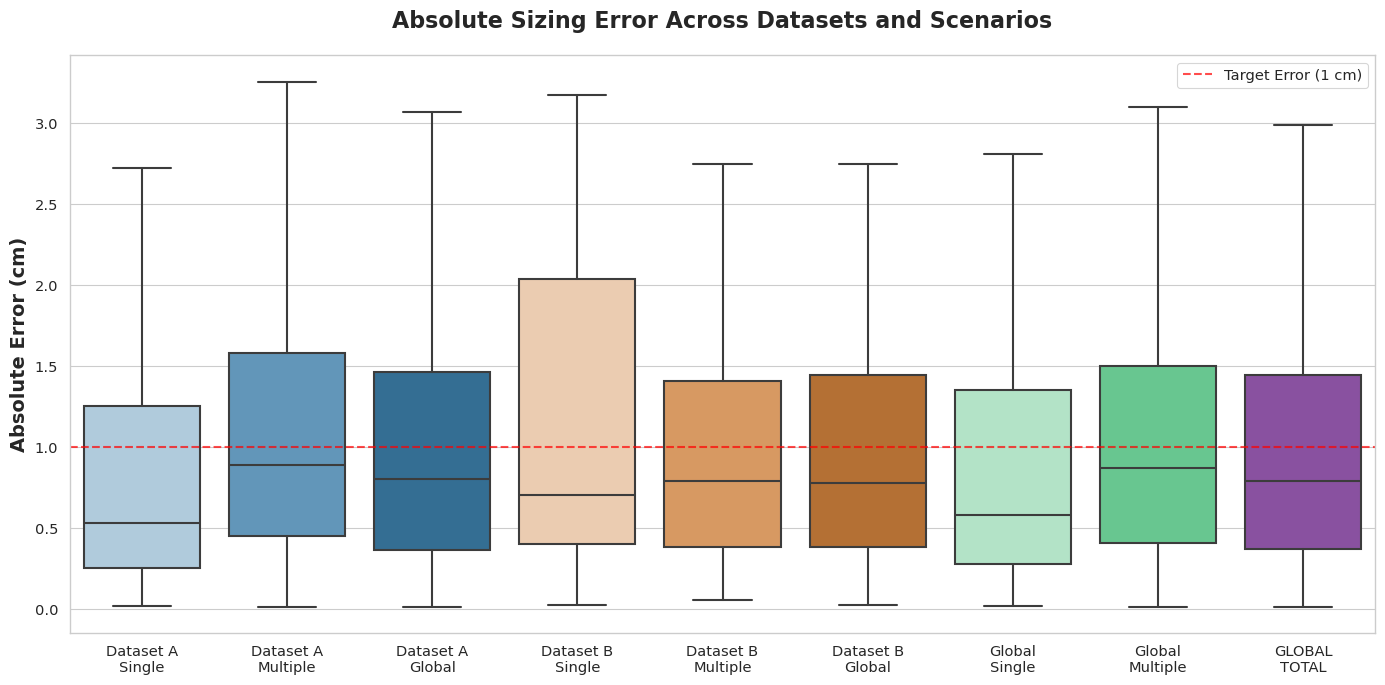


                                   METRICS BY SPECIES (UNIFIED)
SPECIES                        | Total Tracks | Measured   | Success (%)  | MAE (cm)   | STD (cm)   | MAPE (%)  
---------------------------------------------------------------------------------------------------------
D. labrax                      | 342          | 149        | 43.6         | 1.29       | 1.81       | 4.24      
S. scombrus                    | 197          | 95         | 48.2         | 1.24       | 1.58       | 4.29      
M. potassou                    | 91           | 73         | 80.2         | 1.47       | 1.32       | 4.67      
B. boops                       | 121          | 61         | 50.4         | 1.17       | 1.92       | 5.44      



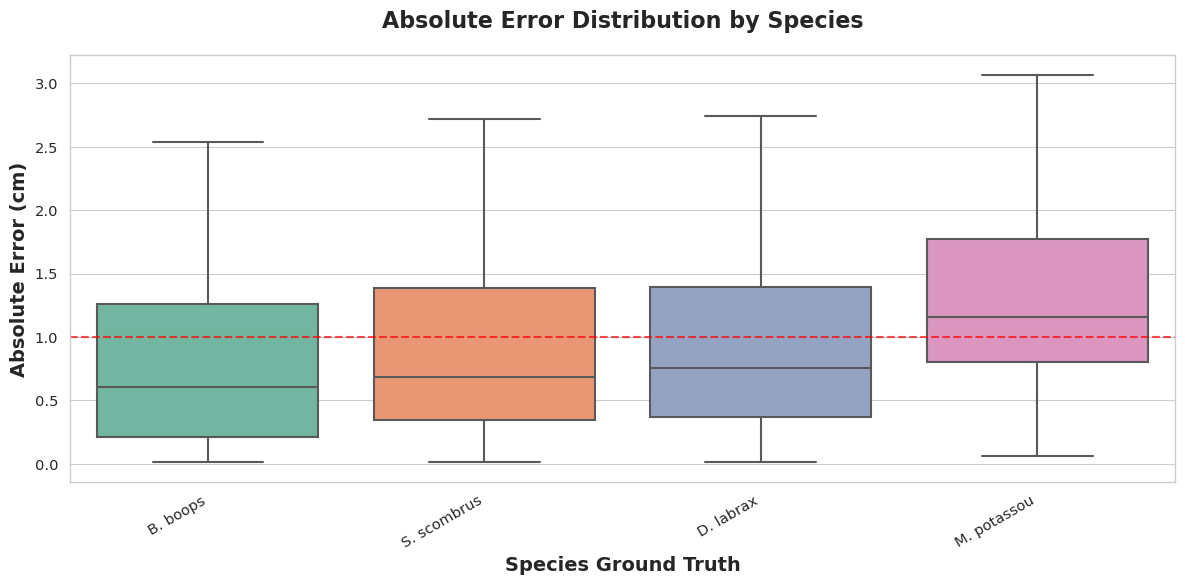

In [57]:

# ===================================================================
# 1. CONFIGURATION & PATHS
# ===================================================================
# Ensure these paths point to where the first script saved the MASTER files
DS1_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_1/aggregated_data/DATASET_1_MASTER_all_fish_all_days.csv")
DS2_MASTER_PATH = Path("/home/slimbook/fish_sizing/ARTICLE/DATASET_2/aggregated_data/DATASET_2_MASTER_all_fish_all_days.csv")

# ===================================================================
# 2. DATA LOADING & TRACK AGGREGATION
# ===================================================================
df_ds1_final, df_ds1_raw= rutils.load_and_filter_dataset(DS1_MASTER_PATH, "Dataset_1",save=True)
df_ds2_final, df_ds2_raw = rutils.load_and_filter_dataset(DS2_MASTER_PATH, "Dataset_2",save=True)

df_all = pd.concat([df_ds1_final, df_ds2_final], ignore_index=True)
df_all_raw = pd.concat([df_ds1_raw, df_ds2_raw], ignore_index=True)

if df_all.empty:
    raise ValueError("No data was loaded. Check your paths!")

global_csv_path = "GLOBAL_FINAL_aggregated_metrics.csv"
df_all.to_csv(global_csv_path, index=False)
print(f"\n💾 Guardado CSV GLOBAL con todos los datos en: {global_csv_path}")

# ===================================================================
# 3. CREATING CATEGORIES FOR ANALYSIS & 4. METRICS TABLE
# ===================================================================
plot_data = []
summary_stats = []

def analyze_group(cat_name, dataset=None, scenario=None):
    # 1. Contar los tracks INICIALES desde el df crudo
    mask_raw = pd.Series(True, index=df_all_raw.index)
    if dataset: mask_raw &= (df_all_raw['dataset'] == dataset)
    if scenario: mask_raw &= (df_all_raw['scenario'] == scenario)
    
    sub_raw = df_all_raw[mask_raw]
    total_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
    
    # Calculate over only the tracks that are real fish ?
    # total_tracks = sub_raw[sub_raw['gt'] > 0]['track_uid'].nunique() if not sub_raw.empty else 0
    
    # 2. Contar los tracks FINALES (y métricas) desde el df procesado
    mask_final = pd.Series(True, index=df_all.index)
    if dataset: mask_final &= (df_all['dataset'] == dataset)
    if scenario: mask_final &= (df_all['scenario'] == scenario)
    
    sub_final = df_all[mask_final]
    measured_tracks = len(sub_final)
    
    # 3. Calcular métricas si hay datos
    if measured_tracks > 0:
        mae = sub_final['abs_error_cm'].mean()
        std = sub_final['abs_error_cm'].std()
        mape = sub_final['rel_error_perc'].mean()
    else:
        mae = None 
        mape = None
        
    # Guardar en la lista de resumen para imprimir la tabla luego
    summary_stats.append({
        'Category': cat_name,
        'Total Tracks': total_tracks,
        'Measured Tracks': measured_tracks,
        'Success Rate (%)': (measured_tracks/total_tracks*100) if total_tracks > 0 else 0,
        'MAE': mae,
        'STD': std,
        'MAPE': mape
    })
    
    # Guardar los datos del grupo para el boxplot
    if not sub_final.empty:
        temp = sub_final.copy()
        temp['Analysis_Group'] = cat_name
        plot_data.append(temp)

# Generamos las categorías dinámicamente
analyze_group("Dataset A\nSingle", dataset='Dataset_1', scenario='single_fish')
analyze_group("Dataset A\nMultiple", dataset='Dataset_1', scenario='multiple_fish')
analyze_group("Dataset A\nGlobal", dataset='Dataset_1')

analyze_group("Dataset B\nSingle", dataset='Dataset_2', scenario='single_fish')
analyze_group("Dataset B\nMultiple", dataset='Dataset_2', scenario='multiple_fish')
analyze_group("Dataset B\nGlobal", dataset='Dataset_2')

analyze_group("Global\nSingle", scenario='single_fish')
analyze_group("Global\nMultiple", scenario='multiple_fish')
analyze_group("GLOBAL\nTOTAL")

df_summary = pd.DataFrame(summary_stats)
df_plot = pd.concat(plot_data, ignore_index=True)

# IMPRIMIR LA TABLA FINAL
print("\n" + "="*104)
print(f"{'CATEGORY':<30} | {'Total Tracks':<12} | {'Measured':<10} | {'Success (%)':<12} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
print("-" * 104)

for _, row in df_summary.iterrows():
    group_clean = row['Category'].replace("\n", " ")
    print(f"{group_clean:<30} | {row['Total Tracks']:<12} | {row['Measured Tracks']:<10} | {row['Success Rate (%)']:<12.1f} | {row['MAE']:<10.2f} | {row['STD']:<10.2f} | {row['MAPE']:<10.2f}")
print("="*104 + "\n")

# ===================================================================
# 5. PUBLICATION-QUALITY BOXPLOT
# ===================================================================
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

palette = [
    "#A9CCE3", "#5499C7", "#2471A3",  # DS1
    "#F5CBA7", "#EB984E", "#CA6F1E",  # DS2
    "#ABEBC6", "#58D68D", "#8E44AD"   # Globals
]

ax = sns.boxplot(
    data=df_plot, 
    x='Analysis_Group', 
    y='abs_error_cm', 
    palette=palette,
    showfliers=False,
    linewidth=1.5
)

plt.title("Absolute Sizing Error Across Datasets and Scenarios", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
plt.xlabel("", fontsize=14) 

plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
plt.legend()

plt.tight_layout()
plt.savefig("Final_Metrics_Boxplot.png", dpi=300)
plt.show()

# ===================================================================
# 6. METRICS & PLOT BY SPECIES (especie_gt) - UNIFICADO
# ===================================================================
if 'especie_gt' in df_all.columns:
    species_stats = []
    
    # 1. DICCIONARIO DE MAPEO (Traducción a nombres científicos/formales)
    species_mapping = {
        'red': 'D. labrax',
        'black': 'D. labrax',
        'no_mark': 'D. labrax',
        'lubina0': 'D. labrax',
        'llobarro': 'D. labrax',
        
        'ochoa_cinta': 'M. potassou',
        'ochoa_petita': 'M. potassou',
        'ochoa_no_cinta': 'M. potassou',
        
        'fish_1': 'D. sargus',
        'fish_3': 'B. boops',
        'caballa': 'S. scombrus'
    }
    
    # 2. APLICAR EL MAPEO A AMBOS DATAFRAMES
    # Rellenamos NaNs primero, luego aplicamos el replace. 
    # Si alguna etiqueta no está en el diccionario, se quedará con su nombre original.
    df_all_raw['especie_gt_clean'] = df_all_raw['especie_gt'].fillna('Unknown').replace(species_mapping)
    df_all['especie_gt_clean'] = df_all['especie_gt'].fillna('Unknown').replace(species_mapping)
    
    # Sacamos las especies únicas ya unificadas
    unique_species = df_all_raw['especie_gt_clean'].unique()
    
    print("\n" + "="*105)
    print(" " * 35 + "METRICS BY SPECIES (UNIFIED)")
    print("="*105)
    print(f"{'SPECIES':<30} | {'Total Tracks':<12} | {'Measured':<10} | {'Success (%)':<12} | {'MAE (cm)':<10} | {'STD (cm)':<10} | {'MAPE (%)':<10}")
    print("-" * 105)
    
    for species in unique_species:
        # Total tracks crudos para esta especie unificada
        sub_raw = df_all_raw[df_all_raw['especie_gt_clean'] == species]
        total_s_tracks = sub_raw['track_uid'].nunique() if not sub_raw.empty else 0
        
        # Si quiero quitar los falsos positivos
        # total_s_tracks = sub_raw[sub_raw['gt'] > 0]['track_uid'].nunique() if not sub_raw.empty else 0
        
        # Tracks medidos y métricas para esta especie unificada
        sub_final = df_all[df_all['especie_gt_clean'] == species]
        measured_s_tracks = len(sub_final)
        
        if measured_s_tracks > 0:
            mae = sub_final['abs_error_cm'].mean()
            std = sub_final['abs_error_cm'].std()
            mape = sub_final['rel_error_perc'].mean()
        else:
            mae = std = mape = 0.0
            
        success_perc = (measured_s_tracks/total_s_tracks*100) if total_s_tracks > 0 else 0
            
        print(f"{species:<30} | {total_s_tracks:<12} | {measured_s_tracks:<10} | {success_perc:<12.1f} | {mae:<10.2f} | {std:<10.2f} | {mape:<10.2f}")
        
    print("="*105 + "\n")

    # ---- BOXPLOT POR ESPECIE UNIFICADA ----
    if len(df_all) > 0:
        plt.figure(figsize=(12, 6))
        sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
        
        # Ordenamos las especies por la mediana del error
        order = df_all.groupby('especie_gt_clean')['abs_error_cm'].median().sort_values().index
        
        ax2 = sns.boxplot(
            data=df_all, 
            x='especie_gt_clean', 
            y='abs_error_cm', 
            order=order,
            palette="Set2", 
            showfliers=False,
            linewidth=1.5
        )
        
        plt.title("Absolute Error Distribution by Species", fontsize=16, fontweight='bold', pad=20)
        plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
        plt.xlabel("Species Ground Truth", fontsize=14, fontweight='bold')
        
        plt.axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Target Error (1 cm)')
        
        # Ajustamos las etiquetas del eje X por si los nombres científicos son largos
        plt.xticks(rotation=30, ha='right') 
        
        # Si usaste paleta 'Set2' o similar sin un 'hue', no hace falta legend() aquí.
        
        plt.tight_layout()
        plt.savefig("Final_Metrics_Boxplot_Species.png", dpi=300)
        plt.show()
else:
    print("⚠️ No 'especie_gt' column found in the dataset. Skipping species analysis.")
    

Evaluating Angles: 100%|██████████| 9/9 [00:33<00:00,  3.73s/it]


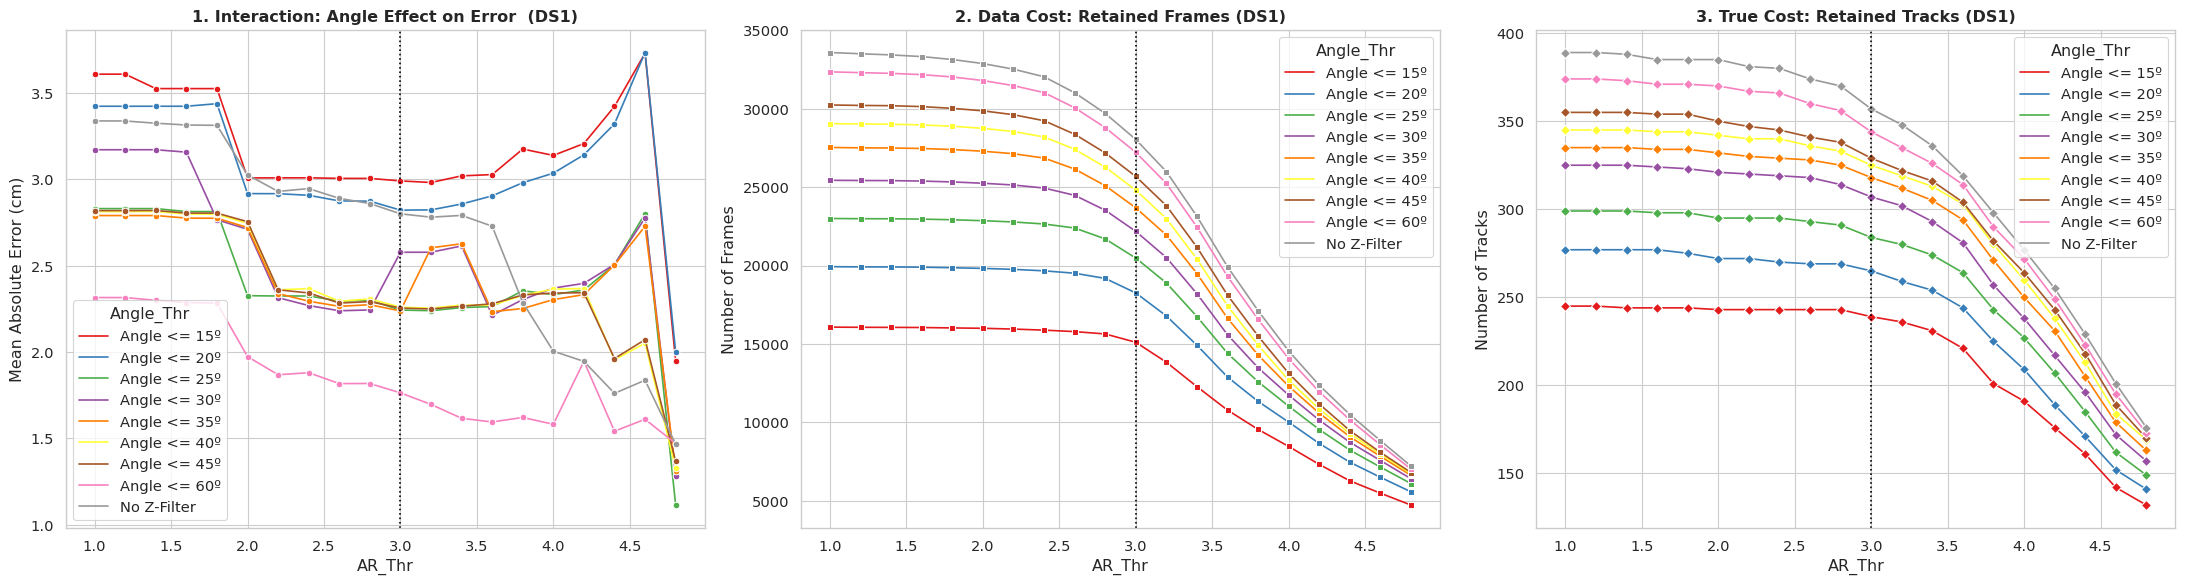

Evaluating Angles: 100%|██████████| 9/9 [00:10<00:00,  1.19s/it]


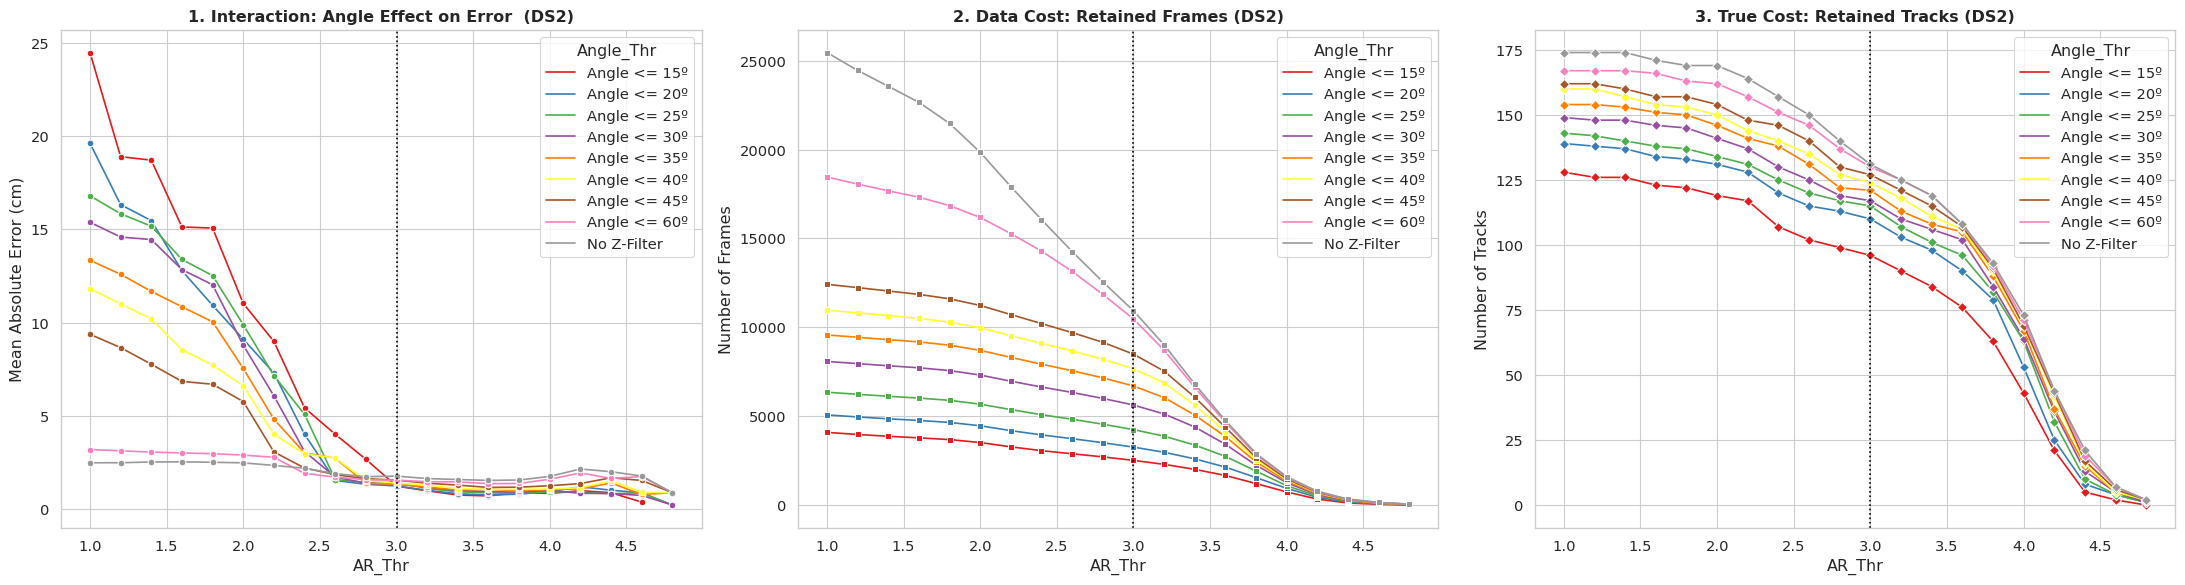

,Angle_Thr,AR_Thr,Error_cm,Frames,Tracks
0,Angle <= 15º,1.0,24.480857,4090,128
1,Angle <= 15º,1.2,18.897578,3974,126
2,Angle <= 15º,1.4,18.711019,3870,126
3,Angle <= 15º,1.6,15.130144,3782,123
4,Angle <= 15º,1.8,15.069477,3685,122
...,...,...,...,...,...
175,No Z-Filter,4.0,1.757620,1596,73
176,No Z-Filter,4.2,2.154654,775,44
177,No Z-Filter,4.4,2.007303,337,21
178,No Z-Filter,4.6,1.776909,147,7


In [58]:
rutils.plot_thresholds_interaction(df_ds1_raw, ar_range=None, angles_to_test=None, optimal_ar=3,context="DS1")
rutils.plot_thresholds_interaction(df_ds2_raw, ar_range=None, angles_to_test=None, optimal_ar=3,context="DS2")



📊 PLOTS FOR DATASET: DATASET_1

📈 Generating Track Failures Distribution Plot for Dataset_1...


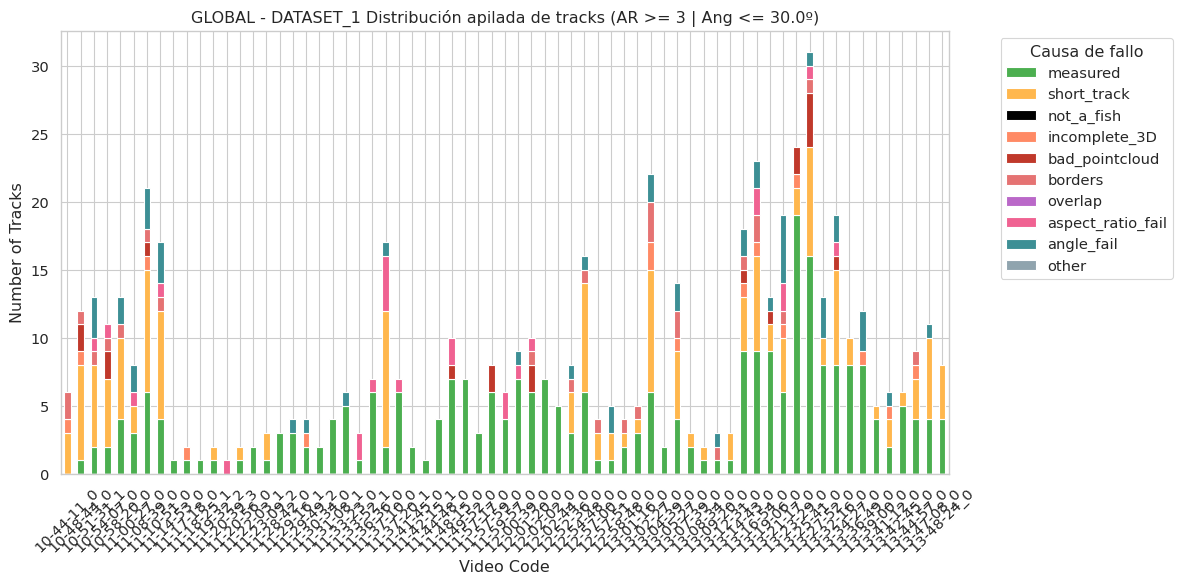

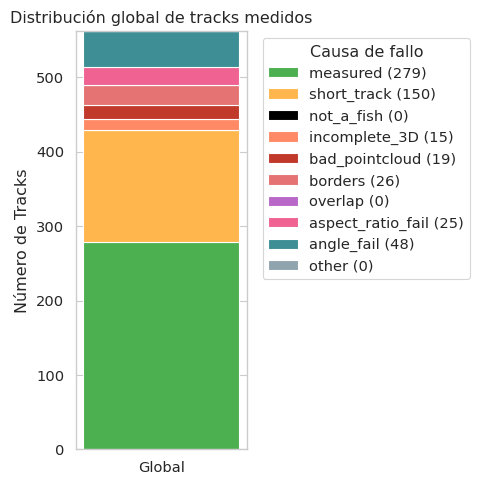


📊 TABLA 1: Distribución Global de Tracks


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,279,49.64
1,short_track,150,26.69
2,not_a_fish,0,0.00
3,incomplete_3D,15,2.67
4,bad_pointcloud,19,3.38
5,borders,26,4.63
6,overlap,0,0.00
7,aspect_ratio_fail,25,4.45
8,angle_fail,48,8.54
9,other,0,0.00



📊 TABLA 2: Desglose por Vídeo


track_failure_reason,measured,short_track,not_a_fish,incomplete_3D,bad_pointcloud,borders,overlap,aspect_ratio_fail,angle_fail,other
source_folder,,,,,,,,,,
10-44-11_0,0,3,0,1,0,2,0,0,0,0
10-48-44_0,1,7,0,1,2,1,0,0,0,0
10-51-31_1,2,6,0,0,0,1,0,1,3,0
10-54-07_0,2,5,0,0,2,1,0,1,0,0
10-58-20_0,4,6,0,0,0,1,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...
13-41-12_0,2,2,0,1,0,0,0,0,1,0
13-42-45_0,5,1,0,0,0,0,0,0,0,0
13-44-57_0,4,3,0,1,0,1,0,0,0,0



📈 Generating Aspect Ratio vs Length Plot for Dataset_1...


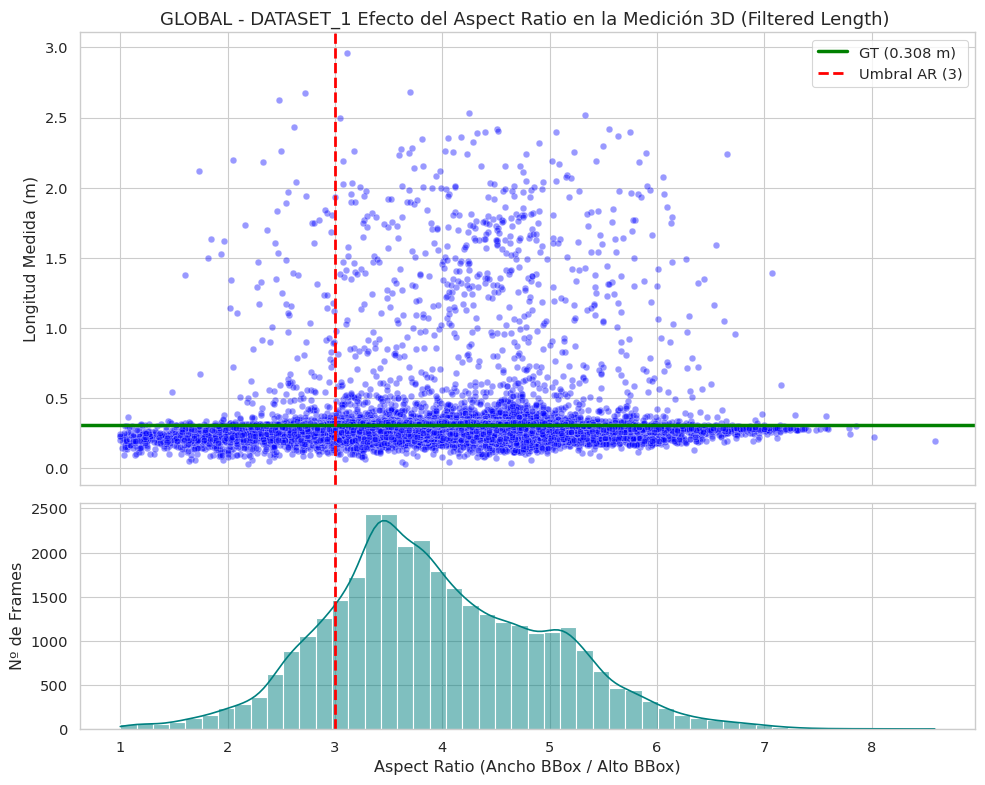


📈 Generating Pipeline Ablation Plots for Dataset_1...
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN without filters)             |  3.07 ± 9.58 cm |   32986 frames |   384 tracks
1. + Filter: No Borders                       |  3.07 ± 9.58 cm |   32986 frames |   384 tracks
2. + Filter: No Overlap                       |  3.04 ± 9.62 cm |   32143 frames |   380 tracks
3. + Filter: is_3D_complete                   |  2.39 ± 5.14 cm |   31467 frames |   369 tracks
4. + Filter: Aspect Ratio >= 3                |  2.22 ± 5.22 cm |   26267 frames |   339 tracks
5. + Filter: Z-Angle <= 30.0º                 |  1.24 ± 1.60 cm |   20606 frames |   294 tracks


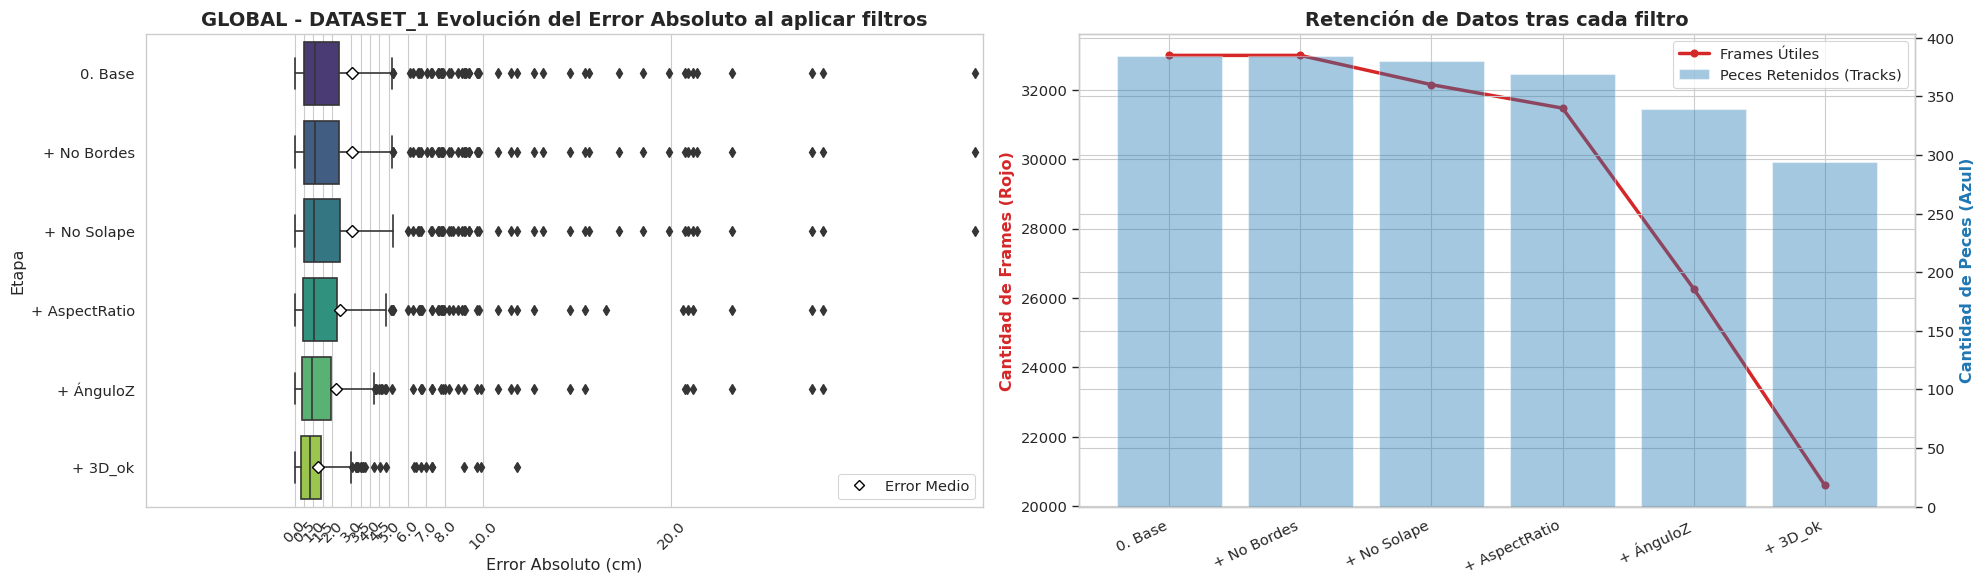


📈 Generating Thresholds Interaction Plot for Dataset_1...


Evaluating Angles: 100%|██████████| 9/9 [00:26<00:00,  2.96s/it]


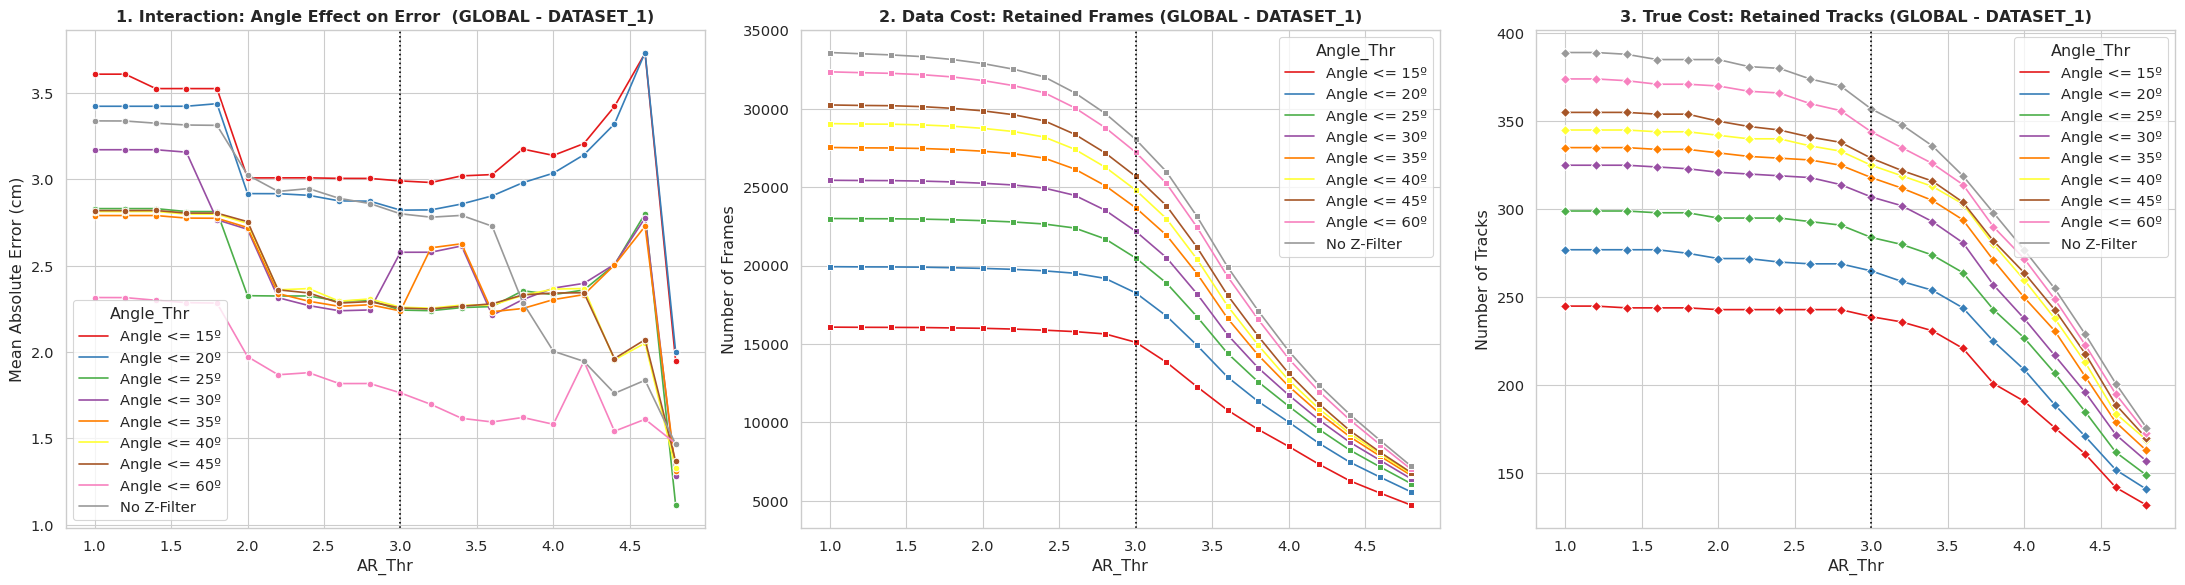


📈 Generating Track Length Histogram for Dataset_1...


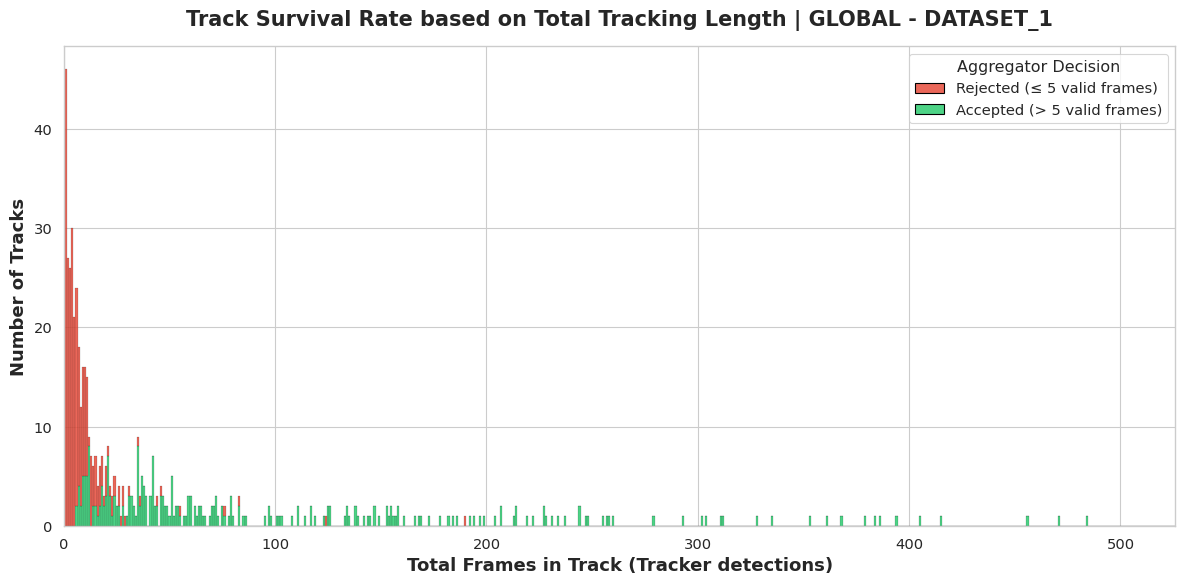



📊 PLOTS FOR DATASET: DATASET_2

📈 Generating Track Failures Distribution Plot for Dataset_2...


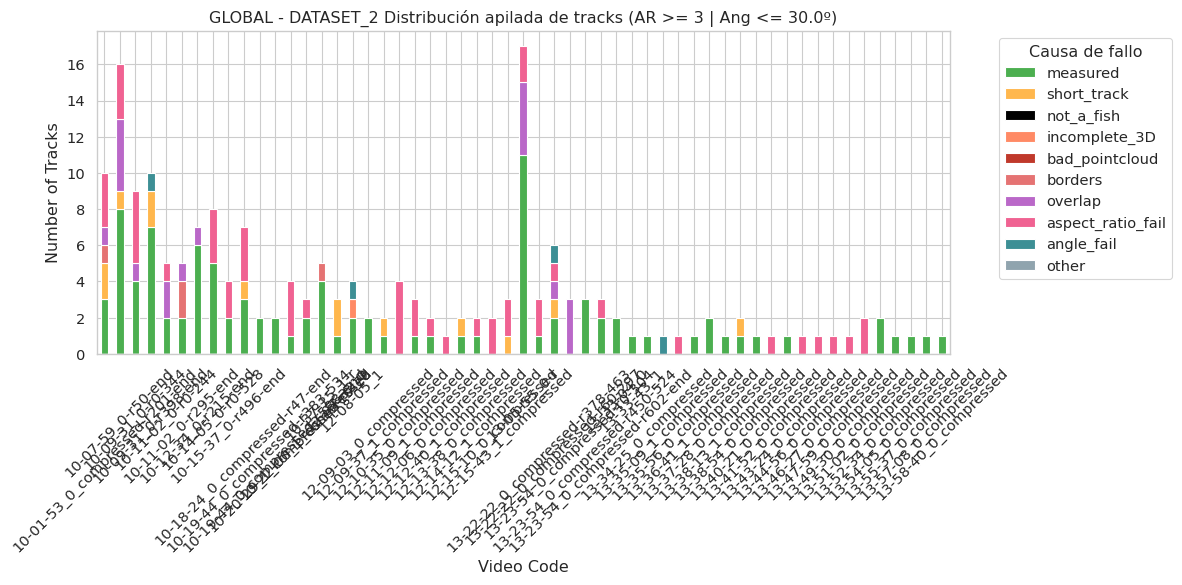

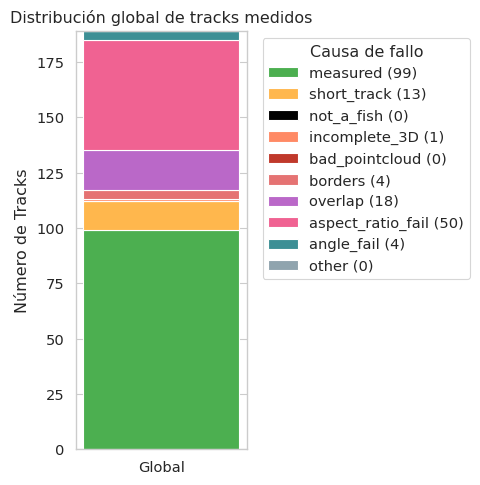


📊 TABLA 1: Distribución Global de Tracks


,Causa de Fallo,Cantidad,Porcentaje (%)
0,measured,99,52.38
1,short_track,13,6.88
2,not_a_fish,0,0.00
3,incomplete_3D,1,0.53
4,bad_pointcloud,0,0.00
5,borders,4,2.12
6,overlap,18,9.52
7,aspect_ratio_fail,50,26.46
8,angle_fail,4,2.12
9,other,0,0.00



📊 TABLA 2: Desglose por Vídeo


track_failure_reason,measured,short_track,not_a_fish,incomplete_3D,bad_pointcloud,borders,overlap,aspect_ratio_fail,angle_fail,other
source_folder,,,,,,,,,,
10-01-53_0_compressed-r201-end,3,2,0,0,0,1,1,3,0,0
10-07-59_0-r50-end,8,1,0,0,0,0,4,3,0,0
10-09-31_0-r0-344,4,0,0,0,0,0,1,4,0,0
10-09-31_0-r398-end,7,2,0,0,0,0,0,0,1,0
10-11-02_0-r0-244,2,0,0,0,0,0,2,1,0,0
10-11-02_0-r295-end,2,0,0,0,0,2,1,0,0,0
10-12-34_0-r215-end,6,0,0,0,0,0,1,0,0,0
10-14-05_0-r0-528,5,0,0,0,0,0,0,3,0,0
10-15-37_0-r496-end,2,0,0,0,0,0,0,2,0,0



📈 Generating Aspect Ratio vs Length Plot for Dataset_2...


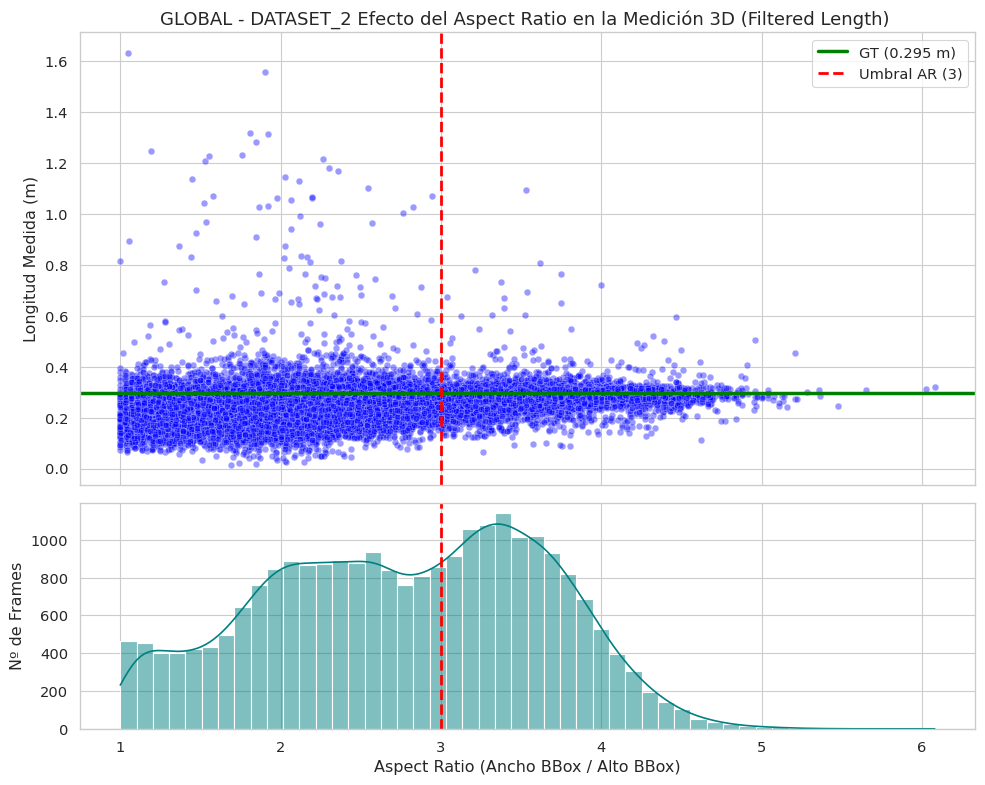


📈 Generating Pipeline Ablation Plots for Dataset_2...
ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN without filters)             |  2.54 ± 3.12 cm |   24416 frames |   173 tracks
1. + Filter: No Borders                       |  2.54 ± 3.12 cm |   24416 frames |   173 tracks
2. + Filter: No Overlap                       |  2.45 ± 3.06 cm |   21778 frames |   164 tracks
3. + Filter: is_3D_complete                   |  2.48 ± 3.09 cm |   21497 frames |   164 tracks
4. + Filter: Aspect Ratio >= 3                |  1.55 ± 1.90 cm |    9281 frames |   120 tracks
5. + Filter: Z-Angle <= 30.0º                 |  1.38 ± 1.74 cm |    4504 frames |   102 tracks


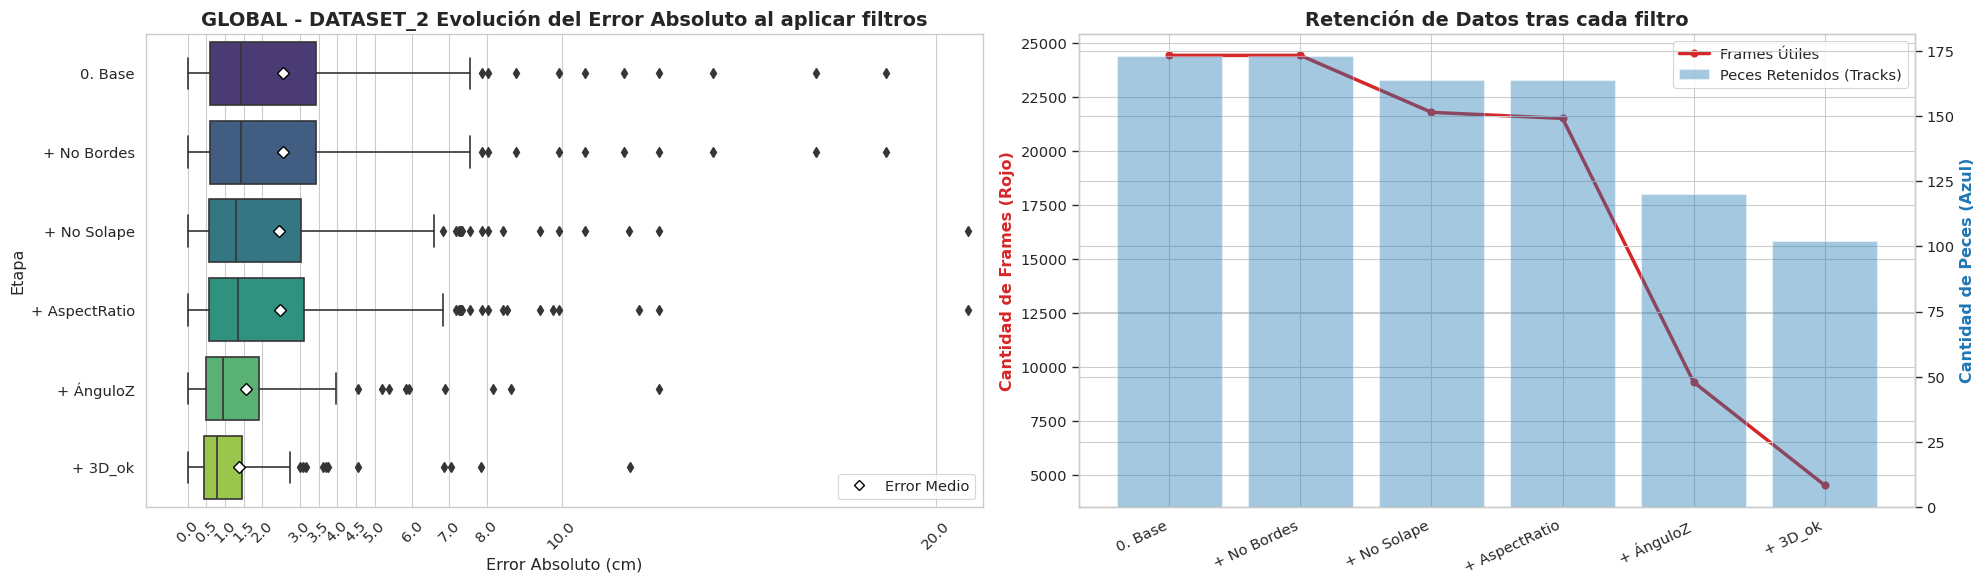


📈 Generating Thresholds Interaction Plot for Dataset_2...


Evaluating Angles: 100%|██████████| 9/9 [00:07<00:00,  1.13it/s]


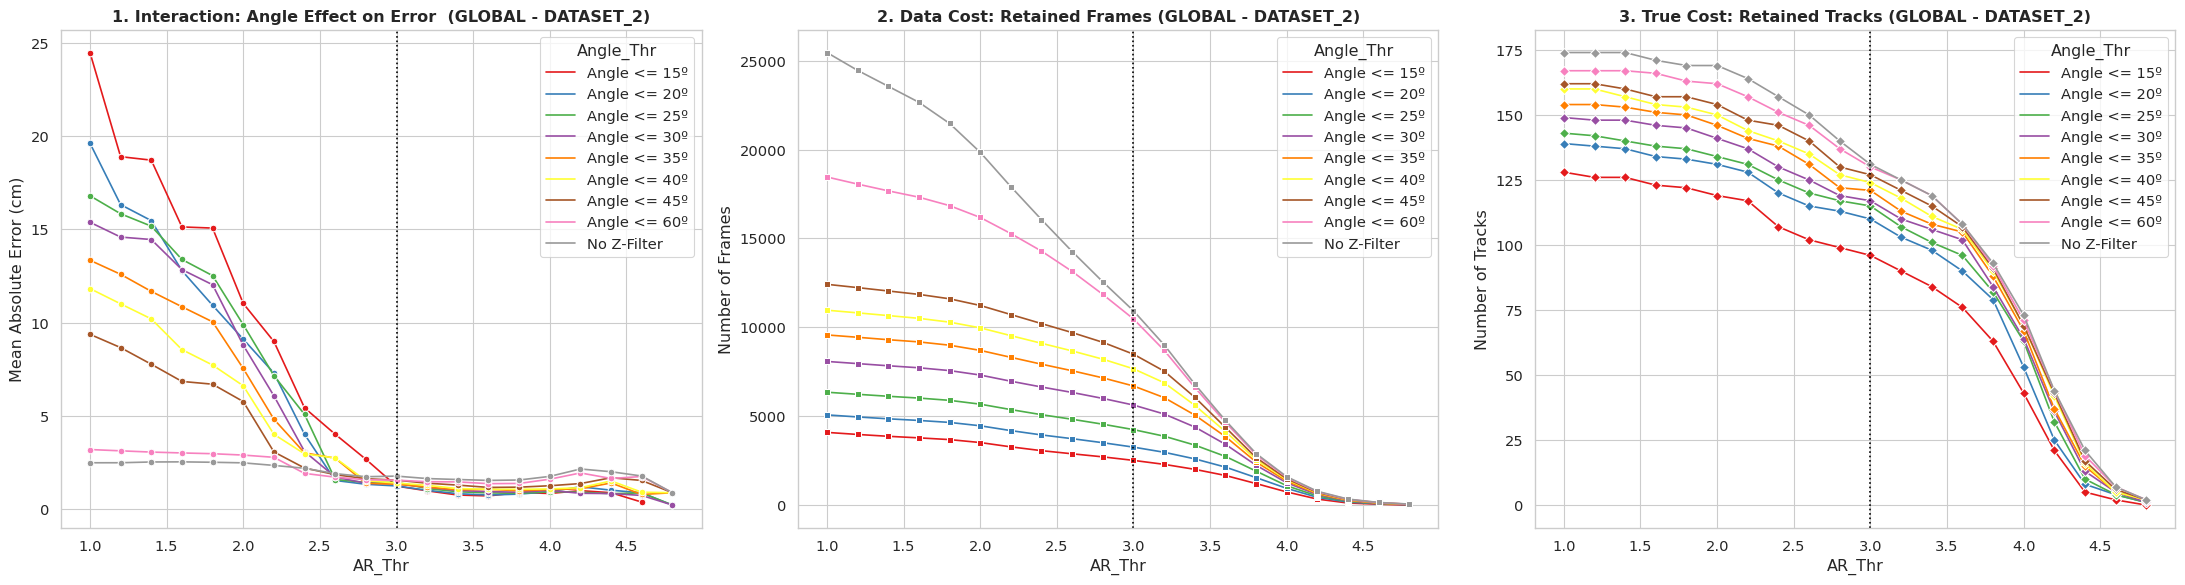


📈 Generating Track Length Histogram for Dataset_2...


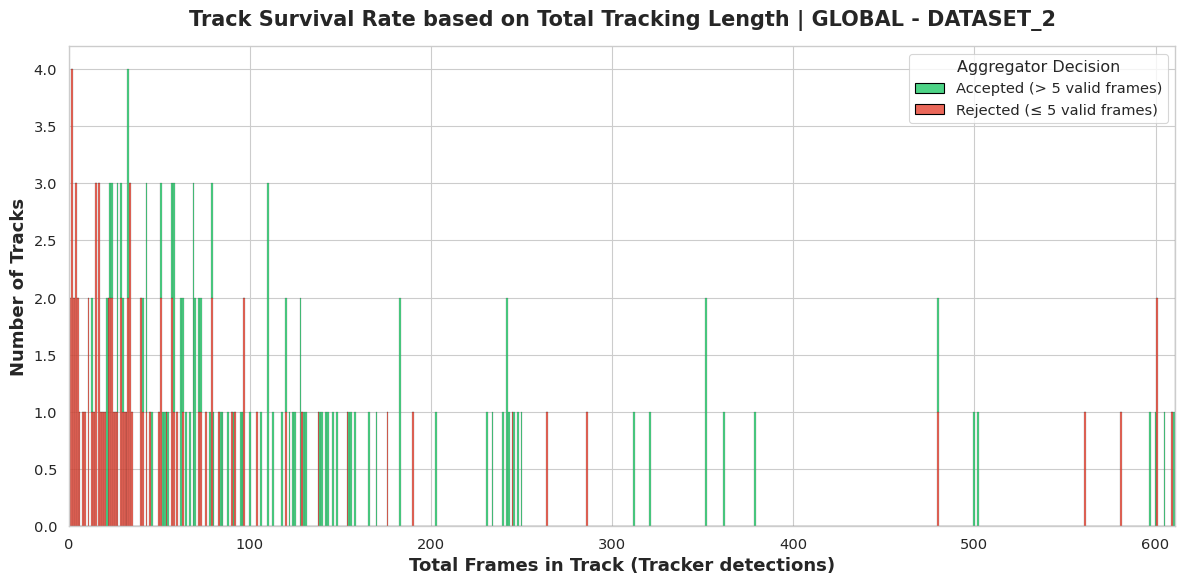

In [59]:
# ===================================================================
# 7. METRICS & PLOTS BY DATASET (Ablation, Geometry & Track Length)
# ===================================================================
datasets = df_all_raw['dataset'].unique()

for ds in datasets:
    cprint(f"\n\n{'='*70}", "white", "on_magenta", attrs=["bold"])
    cprint(f"📊 PLOTS FOR DATASET: {ds.upper()}", "white", "on_magenta", attrs=["bold"])
    cprint(f"{'='*70}", "white", "on_magenta", attrs=["bold"])
    
    # Filtrar el dataframe raw para el dataset actual
    df_ds_raw = df_all_raw[df_all_raw['dataset'] == ds].copy()
    
    # Necesitamos df_final para el plot de track length
    df_ds_final = df_all[df_all['dataset'] == ds] if not df_all.empty else pd.DataFrame()
    
    context_label = f"GLOBAL - {ds.upper()}"
    
    # 7.1. Frame Failures Stacked Bar
    # print(f"\n📈 Generating Frame Failures Plot for {ds}...")
    # rutils.plot_frame_failures(
    #     df_ds_raw, 
    #     aspect_ratio_thr=ASPECT_RATIO_THR, 
    #     angle_thr=ANGLE_THR,
    #     figsize_video=(12,6), 
    #     figsize_global=(5,5), 
    #     show_global=True,
    #     context_label=context_label
    # )

    # 7.2. Track Failure Distribution
    print(f"\n📈 Generating Track Failures Distribution Plot for {ds}...")
    rutils.plot_tracks_failure_distribution(
        df_ds_raw, 
        aspect_ratio_thr=ASPECT_RATIO_THR, 
        angle_thr=ANGLE_THR,
        show_global=True, 
        figsize_video=(12,6), 
        figsize_global=(5,5),
        context_label=context_label
    )

    # 7.3. Aspect Ratio vs Length
    print(f"\n📈 Generating Aspect Ratio vs Length Plot for {ds}...")
    rutils.plot_aspect_ratio_vs_length(
        df_ds_raw, 
        ASPECT_RATIO_THR=ASPECT_RATIO_THR, 
        figsize=(10, 8),
        context_label=context_label
    ) 
    
    # 7.4. Gráfica de Cascada (Ablation)
    print(f"\n📈 Generating Pipeline Ablation Plots for {ds}...")
    stages_dict, agg_stages_dict = rutils.plot_ablation_pipeline(
        df_ds_raw, 
        ASPECT_RATIO_THR=ASPECT_RATIO_THR, 
        ANGLE_THR=ANGLE_THR,
        context_label=context_label  
    )
    
    # 7.5. Interacción de umbrales
    print(f"\n📈 Generating Thresholds Interaction Plot for {ds}...")
    rutils.plot_thresholds_interaction(
        df_ds_raw, 
        optimal_ar=ASPECT_RATIO_THR, 
        context=context_label
    )

    # # 7.6. Relación de Error vs Geometría (Raw y Aislado)
    # print(f"\n📈 Generating Error vs Geometry Analysis Plots for {ds}...")
    # rutils.plot_error_vs_geometry(
    #     df_ds_raw, 
    #     ar_thr=ASPECT_RATIO_THR, 
    #     angle_thr=ANGLE_THR, 
    #     context_label=context_label
    # )

    # # 7.7. Error vs Track Length
    # print(f"\n📈 Generating Track Error vs Length Plot for {ds}...")
    # rutils.plot_error_vs_track_length(
    #     df_raw=df_ds_raw, 
    #     df_final=df_ds_final,
    #     context_label=context_label,
    #     min_frames_thr=5
    # )

    # 7.8. Track Length Histogram
    print(f"\n📈 Generating Track Length Histogram for {ds}...")
    rutils.plot_track_length_histogram(
        df_ds_raw, 
        min_frames_thr=5,
        context_label=context_label
    )

In [60]:
# 1. Filtramos específicamente el Dataset 1 y Multiple Fish
mask = (df_all_raw['dataset'] == 'Dataset_1') & (df_all_raw['scenario'] == 'multiple_fish')
df_subset = df_all_raw[mask]

# 2. Contamos cuántas filas (frames) tiene cada track_uid
track_lengths = df_subset.groupby('track_uid').size()

# 3. Filtramos los que tienen 5 frames o menos
short_tracks = track_lengths[track_lengths <= 5]

print(f"🐟 Total tracks en DS1 Multiple: {len(track_lengths)}")
print(f"🤏 Tracks con 5 frames o menos: {len(short_tracks)}")

if len(short_tracks) > 0:
    print("\n🔍 Detalle de los short tracks (track_uid : número de frames):")
    print(short_tracks)
else:
    print("\n🤯 Efectivamente, NO HAY NINGUNO en el DataFrame.")

🐟 Total tracks en DS1 Multiple: 330
🤏 Tracks con 5 frames o menos: 52

🔍 Detalle de los short tracks (track_uid : número de frames):
track_uid
Dataset_1_2024_11_28_13-14-43_0_11    3
Dataset_1_2024_11_28_13-14-43_0_40    2
Dataset_1_2024_11_28_13-14-43_0_46    5
Dataset_1_2024_11_28_13-14-43_0_59    5
Dataset_1_2024_11_28_13-16-54_0_15    3
Dataset_1_2024_11_28_13-16-54_0_39    5
Dataset_1_2024_11_28_13-16-54_0_4     1
Dataset_1_2024_11_28_13-16-54_0_40    2
Dataset_1_2024_11_28_13-16-54_0_48    2
Dataset_1_2024_11_28_13-16-54_0_74    1
Dataset_1_2024_11_28_13-16-54_0_9     4
Dataset_1_2024_11_28_13-19-06_0_13    1
Dataset_1_2024_11_28_13-19-06_0_18    1
Dataset_1_2024_11_28_13-21-17_0_36    2
Dataset_1_2024_11_28_13-21-17_0_38    3
Dataset_1_2024_11_28_13-21-17_0_67    5
Dataset_1_2024_11_28_13-21-17_0_73    5
Dataset_1_2024_11_28_13-23-29_0_33    2
Dataset_1_2024_11_28_13-23-29_0_57    3
Dataset_1_2024_11_28_13-25-41_0_15    5
Dataset_1_2024_11_28_13-25-41_0_25    1
Dataset_1_2024_11


📊 Analyzing global track failure causes (Stacked Pipeline)...


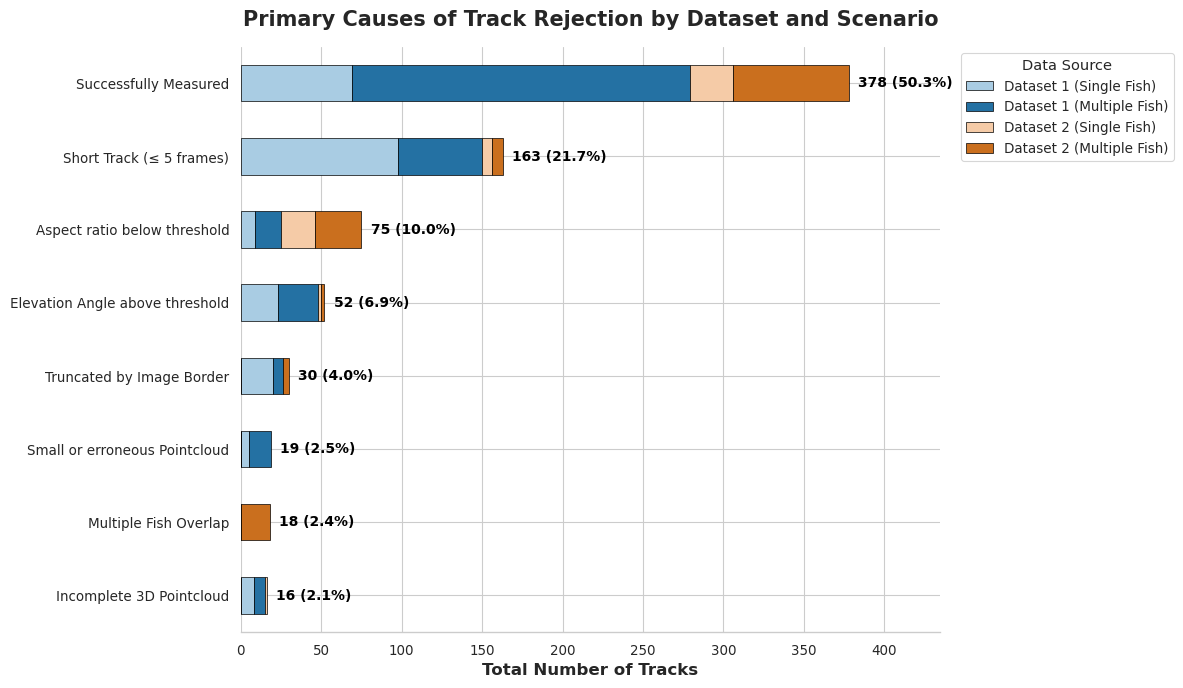


=== RESUMEN TABULAR ===
 Group                            Dataset 1 (Single Fish)  \
Failure Reason                                             
Incomplete 3D Pointcloud                               8   
Multiple Fish Overlap                                  0   
Small or erroneous Pointcloud                          5   
Truncated by Image Border                             20   
Elevation Angle above threshold                       23   
Aspect ratio below threshold                           9   
Short Track (≤ 5 frames)                              98   
Successfully Measured                                 69   

Group                            Dataset 1 (Multiple Fish)  \
Failure Reason                                               
Incomplete 3D Pointcloud                                 7   
Multiple Fish Overlap                                    0   
Small or erroneous Pointcloud                           14   
Truncated by Image Border                                6   
E

In [61]:
def plot_global_failure_causes_stacked(df_all_raw, min_frames=5, save_path="Global_Failure_Causes_Stacked.png"):
    print("\n📊 Analyzing global track failure causes (Stacked Pipeline)...")


    # 2. Sacar la causa principal por track
    failure_series = df_all_raw.groupby('track_uid').apply(
        lambda x: rutils.track_failure_from_frames(x, min_frames=min_frames)
    ).rename('Failure Reason')
    
    # 3. Extraer a qué Dataset y Escenario pertenece cada track
    metadata = df_all_raw.groupby('track_uid').first()[['dataset', 'scenario']]
    
    # 4. Unir la causa con sus metadatos
    track_df = pd.concat([failure_series, metadata], axis=1)
    
    # 5. Mapear etiquetas bonitas
    reason_labels = {
        'measured': 'Successfully Measured',
        'short_track': f'Short Track (≤ {min_frames} frames)',
        'angle_fail': 'Elevation Angle above threshold',
        'aspect_ratio_fail': 'Aspect ratio below threshold',
        'overlap': 'Multiple Fish Overlap',
        'borders': 'Truncated by Image Border',
        'incomplete_3D': 'Incomplete 3D Pointcloud',
        'not_a_fish': 'False Positive / Error',
        'bad_pointcloud': 'Small or erroneous Pointcloud',
        'other': 'Other'
        
    
    }
    
    track_df['Failure Reason'] = track_df['Failure Reason'].map(reason_labels).fillna(track_df['Failure Reason'])
    
    # 6. Crear una columna "Grupo" combinando Dataset y Escenario
    track_df['Group'] = track_df['dataset'].astype(str).str.replace('_', ' ') + " (" + \
                        track_df['scenario'].astype(str).str.replace('_', ' ').str.title() + ")"
    
    # 7. Crear la tabla cruzada (Pivot Table) para apilar
    pivot_df = track_df.groupby(['Failure Reason', 'Group']).size().unstack(fill_value=0)
    
    # Calcular totales para ordenar las barras de mayor a menor
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=True) 
    
    # 🌟 NUEVO: Extraer totales y calcular el gran total para los porcentajes
    totals = pivot_df['Total'].copy()
    grand_total = totals.sum() 
    pivot_df = pivot_df.drop(columns='Total')
    
    # 8. Definir paleta de colores estratégica
    color_map = {
        'Dataset 1 (Single Fish)': '#A9CCE3',   # Azul claro
        'Dataset 1 (Multiple Fish)': '#2471A3', # Azul oscuro
        'Dataset 2 (Single Fish)': '#F5CBA7',   # Naranja claro
        'Dataset 2 (Multiple Fish)': '#CA6F1E'  # Naranja oscuro
    }
    
    # Ordenar las columnas para que el apilado sea siempre el mismo
    ordered_cols = [c for c in color_map.keys() if c in pivot_df.columns]
    pivot_df = pivot_df[ordered_cols]
    
    # ----------------- PLOT -----------------
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Dibujar las barras apiladas
    pivot_df.plot(
        kind='barh', 
        stacked=True, 
        color=[color_map[c] for c in pivot_df.columns], 
        ax=ax, 
        edgecolor='black', 
        linewidth=0.5
    )
    
    # ----------------- ETIQUETAS -----------------
    plt.title("Primary Causes of Track Rejection by Dataset and Scenario", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Total Number of Tracks", fontsize=12, fontweight='bold')
    plt.ylabel("")
    
    # 🌟 NUEVO: Escribir el Total final Y EL PORCENTAJE al lado de la barra
    max_x = totals.max()
    for i, total in enumerate(totals):
        if total > 0:
            pct = (total / grand_total) * 100
            text_label = f"{int(total)} ({pct:.1f}%)"
            ax.text(total + (max_x * 0.015), i, text_label, va='center', fontweight='bold', fontsize=10, color='black')

    # 🌟 NUEVO: Ampliamos el límite X un poco más (15%) para que quepa el porcentaje sin cortarse
    ax.set_xlim(0, max_x * 1.15)

    # Configurar la leyenda fuera del gráfico
    plt.legend(title="Data Source", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    
    # Limpieza
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return pivot_df


pivot_df = plot_global_failure_causes_stacked(df_all_raw, min_frames=5)
print("\n=== RESUMEN TABULAR ===\n", pivot_df)


📊 Generating Error vs. Number of Valid Frames plot...


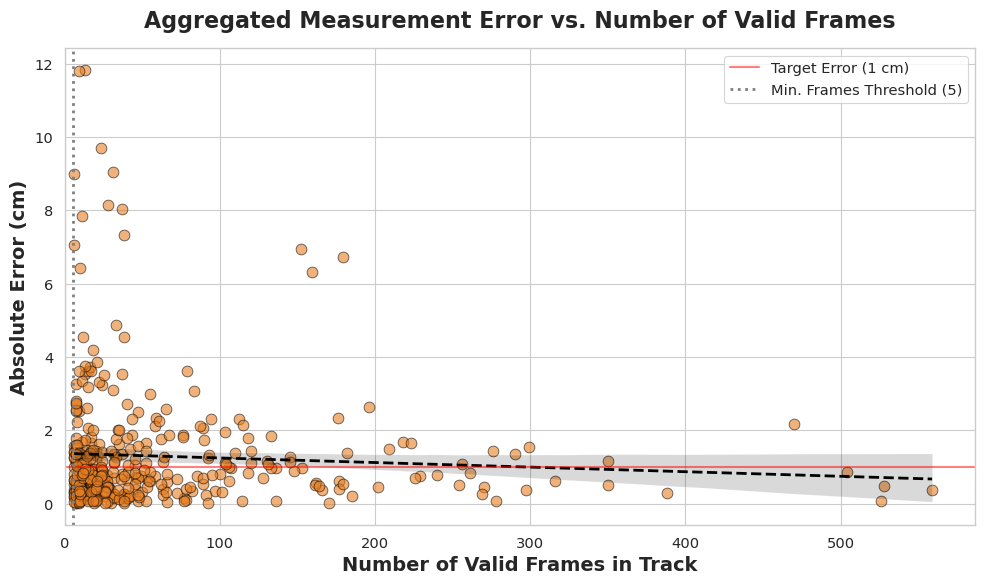

In [62]:
# ===================================================================
# 9. ERROR ANALYSIS VS NUMBER OF VALID FRAMES (AGGREGATED TRACKS)
# ===================================================================
print("\n📊 Generating Error vs. Number of Valid Frames plot...")

# Comprobamos que existan las columnas en el dataframe final
if 'n_frames_validos' in df_all.columns and 'abs_error_cm' in df_all.columns:
    # Filtramos nulos por si acaso
    df_plot_agg = df_all.dropna(subset=['abs_error_cm', 'n_frames_validos']).copy()
    
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    
    # Scatter plot: Cada punto es UN PEZ (Track final)
    ax = sns.scatterplot(
        data=df_plot_agg, 
        x='n_frames_validos', 
        y='abs_error_cm', 
        alpha=0.6,          # Transparencia media porque habrá superposiciones
        color='#E67E22',    # Un naranja elegante
        edgecolor='black',  # Borde para que los puntos destaquen
        s=60                # Tamaño del punto
    )
    
    # Añadimos la línea de tendencia (Regresión)
    sns.regplot(
        data=df_plot_agg, 
        x='n_frames_validos', 
        y='abs_error_cm', 
        scatter=False, 
        color='black', 
        line_kws={'linestyle':'--', 'linewidth': 2}, 
        ax=ax
    )
    
    # Añadimos la línea horizontal roja de tu objetivo de error (1 cm)
    ax.axhline(y=1.0, color='red', linestyle='-', linewidth=1.5, alpha=0.5, label='Target Error (1 cm)')
    
    plt.title("Aggregated Measurement Error vs. Number of Valid Frames", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Number of Valid Frames in Track", fontsize=14, fontweight='bold')
    plt.ylabel("Absolute Error (cm)", fontsize=14, fontweight='bold')
    
    # Ajustamos el límite del eje X para que empiece en 0 y respire un poco por la derecha
    plt.xlim(0, df_plot_agg['n_frames_validos'].max() * 1.05)
    
    # Añadimos una línea vertical tenue donde está tu umbral de descarte (5 frames)
    # asumiendo que num_tracks_threshold = 5 en tu smart_aggregator
    ax.axvline(x=5, color='gray', linestyle=':', linewidth=2, label='Min. Frames Threshold (5)')
    
    plt.legend()
    plt.tight_layout()
    plt.savefig("Error_vs_NumFrames_Aggregated.png", dpi=300)
    plt.show()
else:
    print("⚠️ Columns 'n_frames_validos' or 'abs_error_cm' not found in df_all. Check your smart_aggregator output.")


📊 Analyzing global track failure causes (Strict Pipeline)...


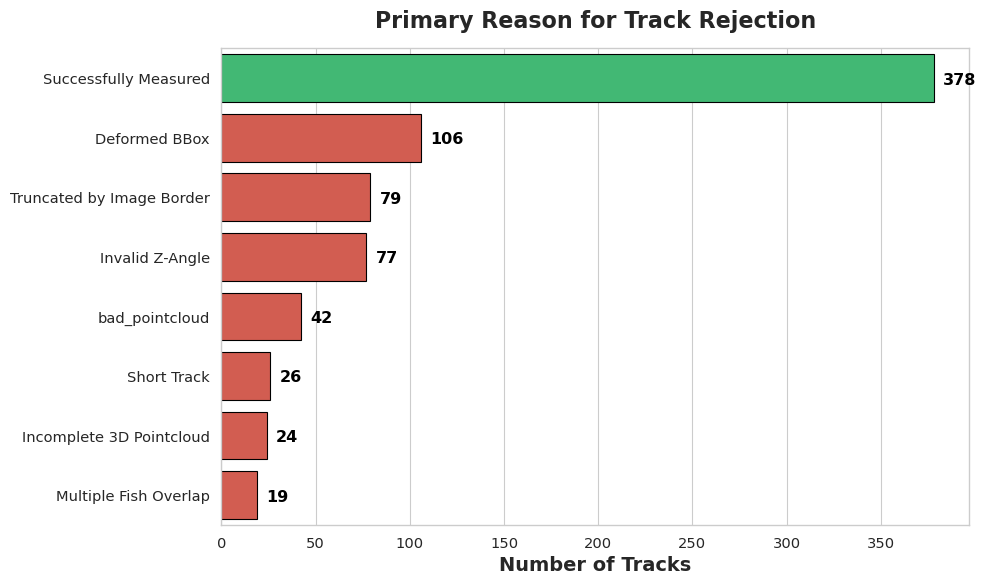


=== STRICT PIPELINE TRACK FAILURE SUMMARY ===
           Failure Reason  Number of Tracks
    Successfully Measured               378
            Deformed BBox               106
Truncated by Image Border                79
          Invalid Z-Angle                77
           bad_pointcloud                42
              Short Track                26
 Incomplete 3D Pointcloud                24
    Multiple Fish Overlap                19


In [63]:
# ===================================================================
# 7. GLOBAL TRACK FAILURE CAUSES ANALYSIS (STRICT PIPELINE)
# ===================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def get_primary_track_failure(track_df, min_frames=5):
    # 1. Contamos cuántos frames perfectos tiene el track
    measured_count = (track_df['failure_reason'] == 'measured').sum()
    
    # 2. Si supera tu umbral del smart_aggregator, entonces SÍ es un éxito
    if measured_count > min_frames:
        return 'measured'
    
    # 3. Si NO supera el umbral, el track se ha descartado. 
    # ¿De qué ha muerto? Miramos los frames que no son perfectos para ver el error predominante.
    bad_frames = track_df[track_df['failure_reason'] != 'measured']
    
    if bad_frames.empty:
        # Si no hay frames malos, significa que todos sus frames eran perfectos, 
        # pero simplemente el pez pasó tan rápido que no llegó a los 6 frames.
        return 'short_track'
    
    # Devolvemos el error MÁS FRECUENTE (la moda) en los frames descartados de este pez
    return bad_frames['failure_reason'].mode()[0]

print("\n📊 Analyzing global track failure causes (Strict Pipeline)...")

# Agrupamos el dataframe global CRUDO por track_uid y sacamos la causa de fallo
global_track_failures = df_all_raw.groupby('track_uid').apply(get_primary_track_failure)

# Contamos cuántos tracks cayeron por cada motivo
failure_counts = global_track_failures.value_counts()

# Preparamos los datos para el plot
plot_df = failure_counts.reset_index()
plot_df.columns = ['Failure Reason', 'Number of Tracks']

# Mapeamos los nombres para que queden más formales en el artículo
reason_labels = {
    'measured': 'Successfully Measured',
    'short_track': 'Short Track',
    'angle_fail': 'Invalid Z-Angle',
    'aspect_ratio_fail': 'Deformed BBox',
    'overlap': 'Multiple Fish Overlap',
    'borders': 'Truncated by Image Border',
    'incomplete_3D': 'Incomplete 3D Pointcloud',
    'not_a_fish': 'False Positive (Not a Fish)',
    'other': 'Other'
}
plot_df['Failure Reason'] = plot_df['Failure Reason'].map(reason_labels).fillna(plot_df['Failure Reason'])

# ----------------- PLOT: BARRAS HORIZONTALES -----------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Definir colores: Verde para el éxito, gris para short track, rojos/naranjas para fallos de filtro
def get_color(reason):
    if reason == 'Successfully Measured': return '#2ECC71' # Verde
    if reason == 'Short Track (≤ 5 valid frames)': return '#95A5A6' # Gris
    return '#E74C3C' # Rojo para los descartes por filtros

colors = [get_color(r) for r in plot_df['Failure Reason']]

ax = sns.barplot(
    data=plot_df, 
    x='Number of Tracks', 
    y='Failure Reason', 
    palette=colors,
    edgecolor='black'
)

plt.title("Primary Reason for Track Rejection", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Tracks", fontsize=14, fontweight='bold')
plt.ylabel("")

# Añadir los números al final de cada barra
for i, v in enumerate(plot_df['Number of Tracks']):
    ax.text(v + 5, i + 0.1, str(v), color='black', fontweight='bold')

plt.tight_layout()
plt.savefig("Global_Failure_Causes_Strict_Barplot.png", dpi=300)
plt.show()

# Imprimir por consola para validar
print("\n=== STRICT PIPELINE TRACK FAILURE SUMMARY ===")
print(plot_df.to_string(index=False))


📊 Analyzing global track failure causes (Stacked Pipeline)...


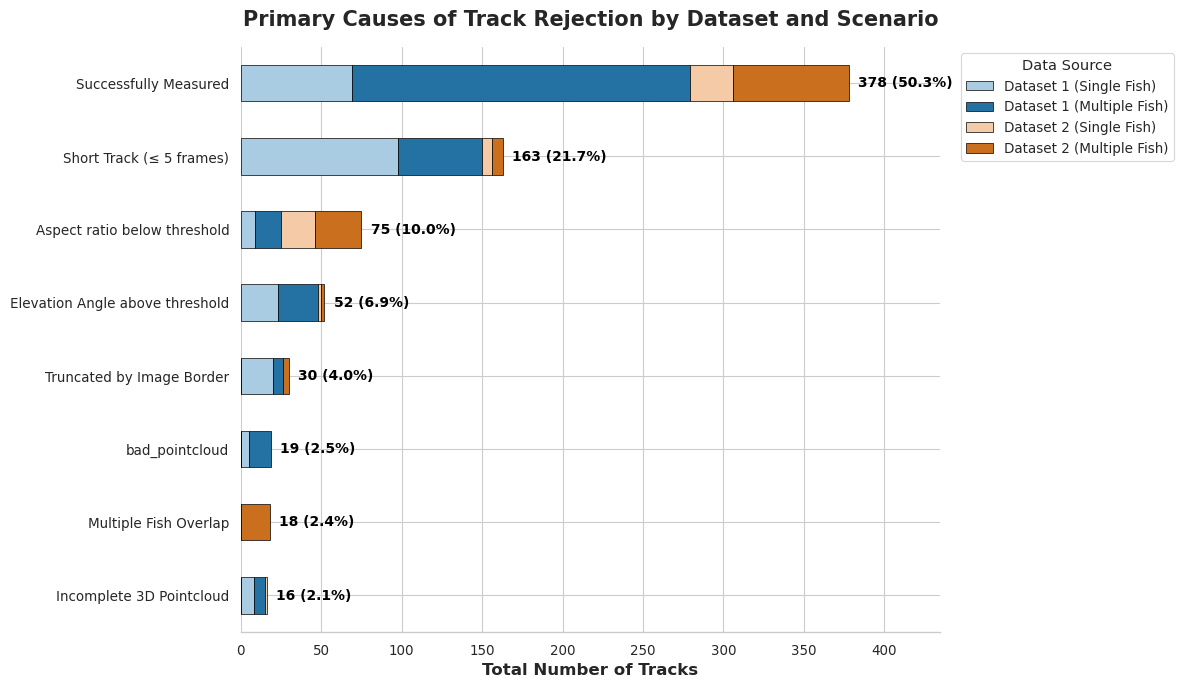


=== RESUMEN TABULAR ===
 Group                            Dataset 1 (Single Fish)  \
Failure Reason                                             
Incomplete 3D Pointcloud                               8   
Multiple Fish Overlap                                  0   
bad_pointcloud                                         5   
Truncated by Image Border                             20   
Elevation Angle above threshold                       23   
Aspect ratio below threshold                           9   
Short Track (≤ 5 frames)                              98   
Successfully Measured                                 69   

Group                            Dataset 1 (Multiple Fish)  \
Failure Reason                                               
Incomplete 3D Pointcloud                                 7   
Multiple Fish Overlap                                    0   
bad_pointcloud                                          14   
Truncated by Image Border                                6   
E

In [64]:
def plot_global_failure_causes_stacked(df_all_raw, min_frames=5, save_path="Global_Failure_Causes_Stacked.png"):
    print("\n📊 Analyzing global track failure causes (Stacked Pipeline)...")
    
    def get_primary_track_failure(track_df):
        # 1️⃣ Filtro implacable: Si el tracker lo perdió antes de 6 frames, 
        # la causa raíz SIEMPRE es que el track es demasiado corto.
        if len(track_df) <= min_frames:
            return 'short_track'
        
        # 2️⃣ Si el track es suficientemente largo, miramos si consiguió el mínimo de medidas buenas
        measured_count = (track_df['failure_reason'] == 'measured').sum()
        if measured_count > min_frames:
            return 'measured'
        
        # 3️⃣ Si es un track largo pero no llegó al mínimo de medidas buenas,
        # buscamos en qué falló principalmente (quitando los frames buenos aislados)
        bad_frames = track_df[track_df['failure_reason'] != 'measured']
        
        # Filtramos 'other' para no enmascarar errores físicos (bordes, ángulos, etc.)
        fallos_reales = bad_frames[bad_frames['failure_reason'] != 'other']['failure_reason']
        
        if not fallos_reales.empty:
            return fallos_reales.mode()[0]
            
        # Si llegamos aquí, es que todos los fallos eran literalmente 'other'
        return 'other'
    
    # 2. Sacar la causa principal por track
    failure_series = df_all_raw.groupby('track_uid').apply(get_primary_track_failure).rename('Failure Reason')
    
    # 3. Extraer a qué Dataset y Escenario pertenece cada track
    metadata = df_all_raw.groupby('track_uid').first()[['dataset', 'scenario']]
    
    # 4. Unir la causa con sus metadatos
    track_df = pd.concat([failure_series, metadata], axis=1)
    
    # 5. Mapear etiquetas bonitas
    reason_labels = {
        'measured': 'Successfully Measured',
        'short_track': f'Short Track (≤ {min_frames} frames)',
        'angle_fail': 'Elevation Angle above threshold',
        'aspect_ratio_fail': 'Aspect ratio below threshold',
        'overlap': 'Multiple Fish Overlap',
        'borders': 'Truncated by Image Border',
        'incomplete_3D': 'Incomplete 3D Pointcloud',
        'not_a_fish': 'False Positive / Error',
        'other': 'Other'
    }
    track_df['Failure Reason'] = track_df['Failure Reason'].map(reason_labels).fillna(track_df['Failure Reason'])
    
    # 6. Crear una columna "Grupo" combinando Dataset y Escenario
    track_df['Group'] = track_df['dataset'].astype(str).str.replace('_', ' ') + " (" + \
                        track_df['scenario'].astype(str).str.replace('_', ' ').str.title() + ")"
    
    # 7. Crear la tabla cruzada (Pivot Table) para apilar
    pivot_df = track_df.groupby(['Failure Reason', 'Group']).size().unstack(fill_value=0)
    
    # Calcular totales para ordenar las barras de mayor a menor
    pivot_df['Total'] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values(by='Total', ascending=True) 
    
    # 🌟 NUEVO: Extraer totales y calcular el gran total para los porcentajes
    totals = pivot_df['Total'].copy()
    grand_total = totals.sum() 
    pivot_df = pivot_df.drop(columns='Total')
    
    # 8. Definir paleta de colores estratégica
    color_map = {
        'Dataset 1 (Single Fish)': '#A9CCE3',   # Azul claro
        'Dataset 1 (Multiple Fish)': '#2471A3', # Azul oscuro
        'Dataset 2 (Single Fish)': '#F5CBA7',   # Naranja claro
        'Dataset 2 (Multiple Fish)': '#CA6F1E'  # Naranja oscuro
    }
    
    # Ordenar las columnas para que el apilado sea siempre el mismo
    ordered_cols = [c for c in color_map.keys() if c in pivot_df.columns]
    pivot_df = pivot_df[ordered_cols]
    
    # ----------------- PLOT -----------------
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Dibujar las barras apiladas
    pivot_df.plot(
        kind='barh', 
        stacked=True, 
        color=[color_map[c] for c in pivot_df.columns], 
        ax=ax, 
        edgecolor='black', 
        linewidth=0.5
    )
    
    # ----------------- ETIQUETAS -----------------
    plt.title("Primary Causes of Track Rejection by Dataset and Scenario", fontsize=15, fontweight='bold', pad=15)
    plt.xlabel("Total Number of Tracks", fontsize=12, fontweight='bold')
    plt.ylabel("")
    
    # 🌟 NUEVO: Escribir el Total final Y EL PORCENTAJE al lado de la barra
    max_x = totals.max()
    for i, total in enumerate(totals):
        if total > 0:
            pct = (total / grand_total) * 100
            text_label = f"{int(total)} ({pct:.1f}%)"
            ax.text(total + (max_x * 0.015), i, text_label, va='center', fontweight='bold', fontsize=10, color='black')

    # 🌟 NUEVO: Ampliamos el límite X un poco más (15%) para que quepa el porcentaje sin cortarse
    ax.set_xlim(0, max_x * 1.15)

    # Configurar la leyenda fuera del gráfico
    plt.legend(title="Data Source", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    
    # Limpieza
    sns.despine(left=True, bottom=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return pivot_df


pivot_df = plot_global_failure_causes_stacked(df_all_raw, min_frames=5)
print("\n=== RESUMEN TABULAR ===\n", pivot_df)


📊 Analyzing global track failure causes (Stacked Pipeline)...


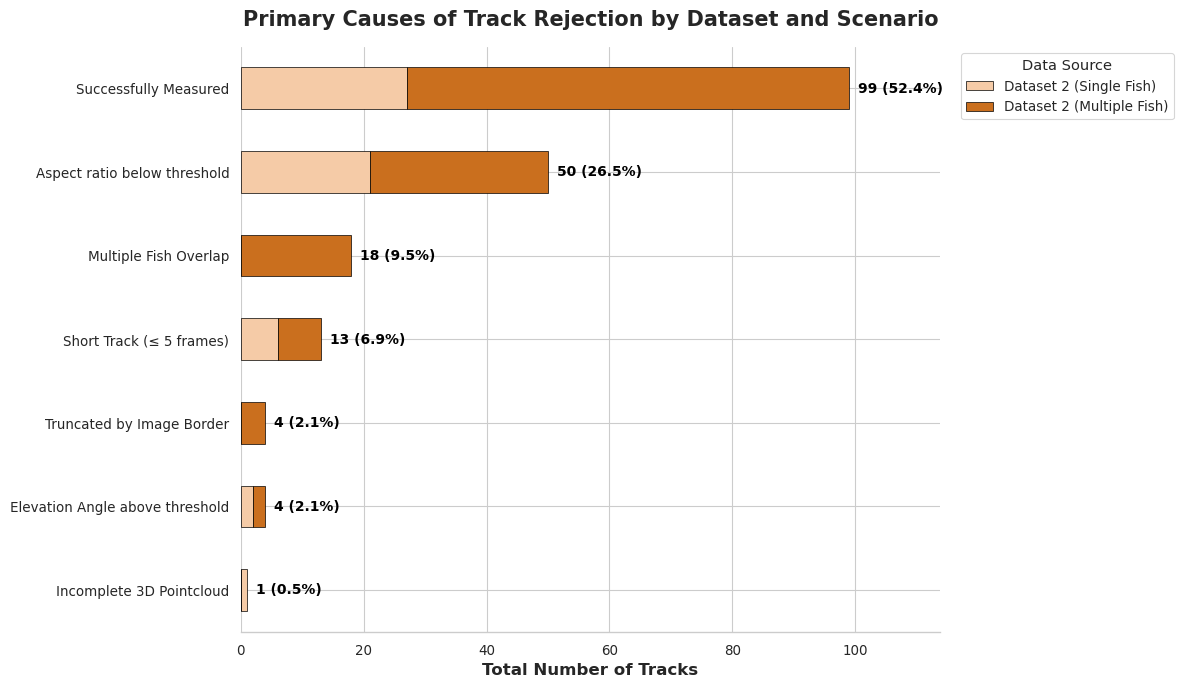


=== RESUMEN TABULAR ===
 Group                            Dataset 2 (Single Fish)  \
Failure Reason                                             
Incomplete 3D Pointcloud                               1   
Elevation Angle above threshold                        2   
Truncated by Image Border                              0   
Short Track (≤ 5 frames)                               6   
Multiple Fish Overlap                                  0   
Aspect ratio below threshold                          21   
Successfully Measured                                 27   

Group                            Dataset 2 (Multiple Fish)  
Failure Reason                                              
Incomplete 3D Pointcloud                                 0  
Elevation Angle above threshold                          2  
Truncated by Image Border                                4  
Short Track (≤ 5 frames)                                 7  
Multiple Fish Overlap                                   18  
Aspect

In [65]:
pivot_df = plot_global_failure_causes_stacked(df_ds2_raw, min_frames=5)
print("\n=== RESUMEN TABULAR ===\n", pivot_df)


📊 Analyzing global track failure causes (Stacked Pipeline)...


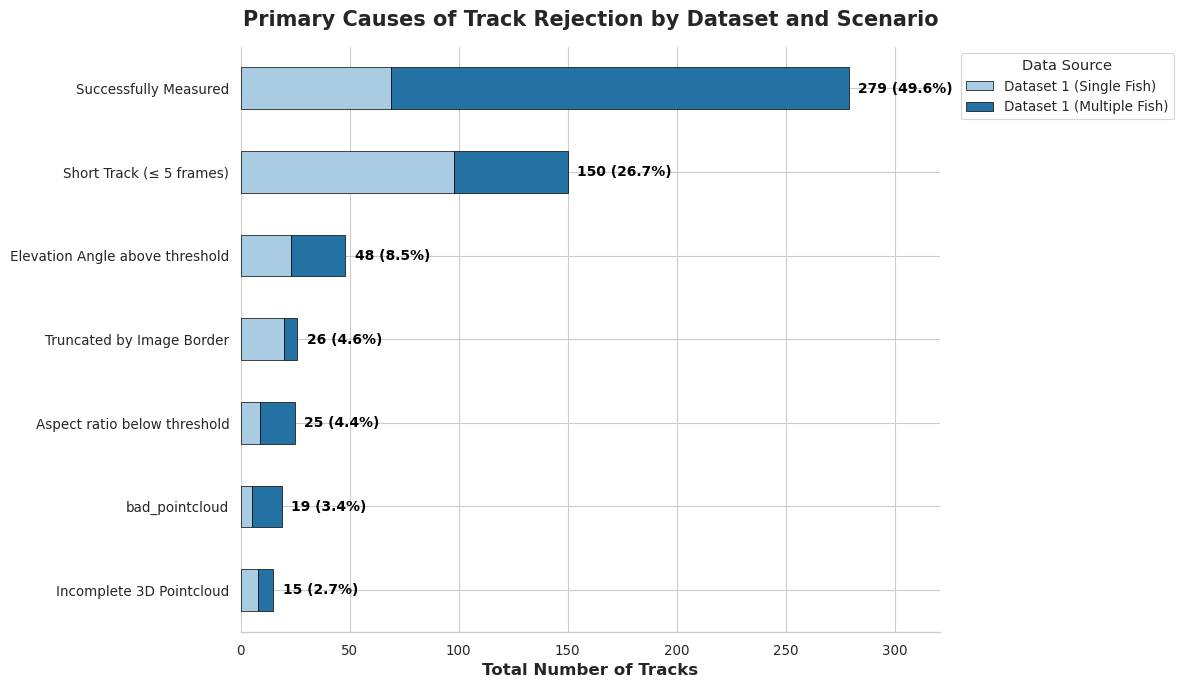


=== RESUMEN TABULAR ===
 Group                            Dataset 1 (Single Fish)  \
Failure Reason                                             
Incomplete 3D Pointcloud                               8   
bad_pointcloud                                         5   
Aspect ratio below threshold                           9   
Truncated by Image Border                             20   
Elevation Angle above threshold                       23   
Short Track (≤ 5 frames)                              98   
Successfully Measured                                 69   

Group                            Dataset 1 (Multiple Fish)  
Failure Reason                                              
Incomplete 3D Pointcloud                                 7  
bad_pointcloud                                          14  
Aspect ratio below threshold                            16  
Truncated by Image Border                                6  
Elevation Angle above threshold                         25  
Short 

In [66]:
pivot_df = plot_global_failure_causes_stacked(df_ds1_raw, min_frames=5)
print("\n=== RESUMEN TABULAR ===\n", pivot_df)

In [67]:
# Miramos cuántos frames totales tiene cada track en el dataset 1 múltiple
test_df = df_all_raw[(df_all_raw['dataset'] == 'Dataset_1') & (df_all_raw['scenario'] == 'multiple_fish')]

track_lengths = test_df.groupby('track_uid').size()

print("--- DEBUG DE LONGITUD DE TRACKS ---")
print(f"Tracks totales en este grupo: {len(track_lengths)}")
print(f"Tracks con 5 frames o menos: {(track_lengths <= 5).sum()}")
print(f"Tracks con 10 frames o menos: {(track_lengths <= 10).sum()}")
print(f"Longitud mínima de un track guardado: {track_lengths.min()} frames")

--- DEBUG DE LONGITUD DE TRACKS ---
Tracks totales en este grupo: 330
Tracks con 5 frames o menos: 52
Tracks con 10 frames o menos: 102
Longitud mínima de un track guardado: 1 frames


In [68]:
# df_ds2_raw[(df_ds2_raw["scenario"] == "single_fish") & (df_ds2_raw["does_overlap"] == "True")]

df_ds2_raw[(df_ds2_raw["does_overlap"] == "True")]

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario,dataset,track_uid


In [69]:
df_ds2_raw

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario,dataset,track_uid
0,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_0,0,255,1,1,False,False,True,2.377709,True,True,[],[ 0.17029 0.10378 0.97991],78.520896,28.391784,0.395964,0.395895,0.418268,29.1,10.489524,36.046476,1.684505,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
1,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_1,0,255,1,1,False,False,True,2.758794,True,True,[],[ 0.16755 0.12004 0.97853],66.659947,34.956321,0.386607,0.313513,0.308890,29.1,2.251299,7.736422,1.664301,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
2,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_2,0,255,1,1,False,False,True,2.917978,True,True,[],[ 0.19632 0.10251 0.97517],76.662597,24.943686,0.502804,0.424774,0.431788,29.1,13.377388,45.970405,1.689802,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
3,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_3,0,255,1,1,False,False,True,3.233875,True,True,[],[ 0.088092 0.073477 0.9934],57.287174,12.869175,0.777680,0.309058,0.300570,29.1,1.805814,6.205548,1.683490,red,angle_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
4,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_4,0,255,1,1,False,False,True,3.393939,True,True,[],[ 0.32802 0.082446 0.94107],58.916219,15.385493,0.530785,0.306474,0.292155,29.1,1.547354,5.317367,1.691556,red,angle_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26206,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_209,0,127,9,1,False,False,True,3.756264,True,True,[],[ 0.716 0.39683 0.57434],34.480758,27.980829,0.314987,0.313961,0.310101,32.3,0.903900,6.280298,1.607512,no_mark,angle_fail,2025_08_21/10-09-31_0-r398-end/9,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_9
26207,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,255,14,1,False,False,True,3.710797,True,True,[],[ 0.94621 0.18708 -0.26397],-15.434967,11.138975,0.274666,0.274631,0.270029,29.1,1.636921,18.020659,1.680929,red,measured,2025_08_21/10-09-31_0-r398-end/14,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_14
26208,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,127,9,1,False,False,True,4.247777,True,True,[],[ 0.70012 0.40641 0.58708],34.512254,29.316305,0.332776,0.317733,0.312440,32.3,0.526670,5.154238,1.609569,no_mark,angle_fail,2025_08_21/10-09-31_0-r398-end/9,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_9
26209,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_211,0,255,14,1,False,False,True,3.639830,True,True,[],[ 0.91769 0.21707 -0.33276],-18.585511,13.240168,0.291738,0.291588,0.282441,29.1,0.058819,12.958749,1.693683,red,measured,2025_08_21/10-09-31_0-r398-end/14,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_14


In [70]:
rutils.plot_smart_filter_explanation_pro(df_ds2_raw, "10_48_44_0", 24)


rutils.plot_track_evolution_detailed(df_raw_agg, "10_48_44_0", 24)

NameError: name 'df_raw_agg' is not defined

In [ ]:
df_ds2_raw[df_ds2_raw["scenario"]=="multiple_fish"]

,video_day,source_folder,video_name,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,aspect_ratio,pointcloud_size_ok,fish_3d_ok,overlapping_fish_ids,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera,especie_gt,failure_reason,unique_track,scenario,dataset,track_uid
0,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_0,0,255,1,1,False,False,True,2.377709,True,True,[],[ 0.17029 0.10378 0.97991],78.520896,28.391784,0.395964,0.395895,0.418268,29.1,10.489524,36.046476,1.684505,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
1,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_1,0,255,1,1,False,False,True,2.758794,True,True,[],[ 0.16755 0.12004 0.97853],66.659947,34.956321,0.386607,0.313513,0.308890,29.1,2.251299,7.736422,1.664301,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
2,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_2,0,255,1,1,False,False,True,2.917978,True,True,[],[ 0.19632 0.10251 0.97517],76.662597,24.943686,0.502804,0.424774,0.431788,29.1,13.377388,45.970405,1.689802,red,aspect_ratio_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
3,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_3,0,255,1,1,False,False,True,3.233875,True,True,[],[ 0.088092 0.073477 0.9934],57.287174,12.869175,0.777680,0.309058,0.300570,29.1,1.805814,6.205548,1.683490,red,angle_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
4,2025_08_21,12-09-37_1_compressed,12-09-37_1_compressed,frame_4,0,255,1,1,False,False,True,3.393939,True,True,[],[ 0.32802 0.082446 0.94107],58.916219,15.385493,0.530785,0.306474,0.292155,29.1,1.547354,5.317367,1.691556,red,angle_fail,2025_08_21/12-09-37_1_compressed/1,single_fish,Dataset_2,Dataset_2_2025_08_21_12-09-37_1_compressed_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26206,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_209,0,127,9,1,False,False,True,3.756264,True,True,[],[ 0.716 0.39683 0.57434],34.480758,27.980829,0.314987,0.313961,0.310101,32.3,0.903900,6.280298,1.607512,no_mark,angle_fail,2025_08_21/10-09-31_0-r398-end/9,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_9
26207,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,255,14,1,False,False,True,3.710797,True,True,[],[ 0.94621 0.18708 -0.26397],-15.434967,11.138975,0.274666,0.274631,0.270029,29.1,1.636921,18.020659,1.680929,red,measured,2025_08_21/10-09-31_0-r398-end/14,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_14
26208,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_210,0,127,9,1,False,False,True,4.247777,True,True,[],[ 0.70012 0.40641 0.58708],34.512254,29.316305,0.332776,0.317733,0.312440,32.3,0.526670,5.154238,1.609569,no_mark,angle_fail,2025_08_21/10-09-31_0-r398-end/9,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_9
26209,2025_08_21,10-09-31_0-r398-end,10-09-31_0-r398-end,frame_211,0,255,14,1,False,False,True,3.639830,True,True,[],[ 0.91769 0.21707 -0.33276],-18.585511,13.240168,0.291738,0.291588,0.282441,29.1,0.058819,12.958749,1.693683,red,measured,2025_08_21/10-09-31_0-r398-end/14,multiple_fish,Dataset_2,Dataset_2_2025_08_21_10-09-31_0-r398-end_14
